# Experiment 7 — Autoencoders, Convolutional Autoencoders, Denoising Autoencoders and Variational Autoencoders

**Course:** CS3807 – Deep Learning Laboratory
**Degree & Branch:** B.Tech Artificial Intelligence & Data Science, Semester V
**Random State:** 109
**Dataset:** MNIST (10,000 train / 2,000 test subset)

This notebook covers the complete required pipeline (Sections 1–27 of the lab manual) plus all Additional Exercises (Section 29). All models train sequentially in this single kernel. Checkpoints (metrics + weights) are saved after every major run to `/kaggle/working/checkpoints/` so a mid-run disconnect does not lose completed work. All figures are saved to `/kaggle/working/plots/` and zipped at the end for download.

**Estimated total runtime on Kaggle GPU (T4/P100): ~75–90 minutes.**


## 1. Setup, Imports, Reproducibility, Checkpointing Utilities

In [1]:
import os, time, json, pickle, zipfile, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib as mpl
from skimage.metrics import structural_similarity as ssim_metric

SEED = 109
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PLOTS_DIR = '/kaggle/working/plots'
CKPT_DIR = '/kaggle/working/checkpoints'
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# Plot style: font size 13-15, bold axes, as required by report formatting spec
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 13
mpl.rcParams['ytick.labelsize'] = 13
mpl.rcParams['legend.fontsize'] = 13
mpl.rcParams['figure.titlesize'] = 15

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Checkpointing utility: save metrics dict as JSON, weights as .h5, after every major run.
# This is insurance against a mid-notebook crash/disconnect losing prior completed sections.

def save_checkpoint(name, metrics_dict, model=None):
    with open(os.path.join(CKPT_DIR, f'{name}_metrics.json'), 'w') as f:
        json.dump(metrics_dict, f, indent=2, default=str)
    if model is not None:
        # Custom subclassed models (e.g. VAE) are not 'built' until called on data once.
        # save_weights fails on an unbuilt model, so force-build with one dummy forward pass.
        if not model.built:
            _ = model(tf.zeros((1, 28, 28, 1)))
        model.save_weights(os.path.join(CKPT_DIR, f'{name}_weights.weights.h5'))
    print(f"[checkpoint saved] {name}")

def save_fig(fig, filename):
    path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f"[plot saved] {filename}")
    plt.show()
    plt.close(fig)

ALL_METRICS = {}  # running collection for final consolidated tables

## 2. Dataset Loading and Preparation

In [3]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

# Recommended laboratory subset: 10,000 train / 2,000 test, seeded for reproducibility
rng = np.random.RandomState(SEED)
train_idx = rng.choice(len(x_train_full), 10000, replace=False)
test_idx = rng.choice(len(x_test_full), 2000, replace=False)

x_train = x_train_full[train_idx].astype('float32') / 255.0
x_test = x_test_full[test_idx].astype('float32') / 255.0
y_train = y_train_full[train_idx]
y_test = y_test_full[test_idx]

# Flattened versions for FC-AE
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

# Channel-dim versions for CAE/VAE
x_train_img = x_train.reshape(-1, 28, 28, 1)
x_test_img = x_test.reshape(-1, 28, 28, 1)

print("Train:", x_train_img.shape, " Test:", x_test_img.shape)
print("Pixel range:", x_train.min(), "-", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (10000, 28, 28, 1)  Test: (2000, 28, 28, 1)
Pixel range: 0.0 - 1.0


## 3. Evaluation Metric Utility (MSE, MAE, SSIM)

In [4]:
def compute_metrics(originals, reconstructions):
    """originals, reconstructions: (N, 28, 28) or (N, 28, 28, 1), range [0,1]"""
    o = originals.reshape(len(originals), 28, 28)
    r = reconstructions.reshape(len(reconstructions), 28, 28)
    mse = np.mean((o - r) ** 2)
    mae = np.mean(np.abs(o - r))
    ssim_vals = [ssim_metric(o[i], r[i], data_range=1.0) for i in range(len(o))]
    mean_ssim = np.mean(ssim_vals)
    return {'MSE': float(mse), 'MAE': float(mae), 'SSIM': float(mean_ssim)}

def count_params(model):
    return int(model.count_params())

## 4. Fully Connected Autoencoder (Section 7–9)

Architecture: 784 → 128 → 32 → **16 (latent)** → 32 → 128 → 784, ReLU hidden, sigmoid output, Adam @ 1e-3, batch 128, 20 epochs, binary cross-entropy.

In [5]:
def build_fc_autoencoder(latent_dim=16):
    inp = layers.Input(shape=(784,), name='fc_input')
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dense(32, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    x = layers.Dense(32, activation='relu')(z)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(784, activation='sigmoid')(x)
    autoencoder = keras.Model(inp, out, name=f'fc_ae_dim{latent_dim}')
    encoder = keras.Model(inp, z, name=f'fc_encoder_dim{latent_dim}')
    autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    return autoencoder, encoder

fc_ae, fc_encoder = build_fc_autoencoder(latent_dim=16)
fc_ae.summary()

I0000 00:00:1790654664.698130      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790654664.704295      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "fc_ae_dim16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc_input (InputLayer)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Expect: ~1-2 minutes on Kaggle GPU
t0 = time.time()
fc_history = fc_ae.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20, batch_size=128, shuffle=True, verbose=1
)
fc_train_time = time.time() - t0
print(f"FC-AE training time: {fc_train_time:.1f}s")

Epoch 1/20
67/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4894

I0000 00:00:1790654669.698970      70 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.3472 - val_loss: 0.2531
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2408 - val_loss: 0.2231
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2091 - val_loss: 0.1927
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1888 - val_loss: 0.1814
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1805 - val_loss: 0.1751
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1742 - val_loss: 0.1682
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1675 - val_loss: 0.1628
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1630 - val_loss: 0.1593
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1590 - val_loss: 0.1554
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1550 - val_loss: 0.1520
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1516 - val_loss: 0.1489
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1482 - val_loss: 0.1455

In [7]:
fc_recon = fc_ae.predict(x_test_flat, verbose=0)
fc_metrics = compute_metrics(x_test_flat, fc_recon)
fc_metrics['Parameters'] = count_params(fc_ae)
fc_metrics['TrainTime_s'] = round(fc_train_time, 1)
print("FC-AE test metrics:", fc_metrics)
ALL_METRICS['FC_AE'] = fc_metrics
save_checkpoint('fc_ae_latent16', fc_metrics, fc_ae)

FC-AE test metrics: {'MSE': 0.02252386510372162, 'MAE': 0.05971858650445938, 'SSIM': 0.7452111643011737, 'Parameters': 211040, 'TrainTime_s': 11.5}
[checkpoint saved] fc_ae_latent16


### Plot 1 — Original vs Reconstructed Images (FC-AE)

[plot saved] 01_fc_ae_original_vs_reconstructed.png


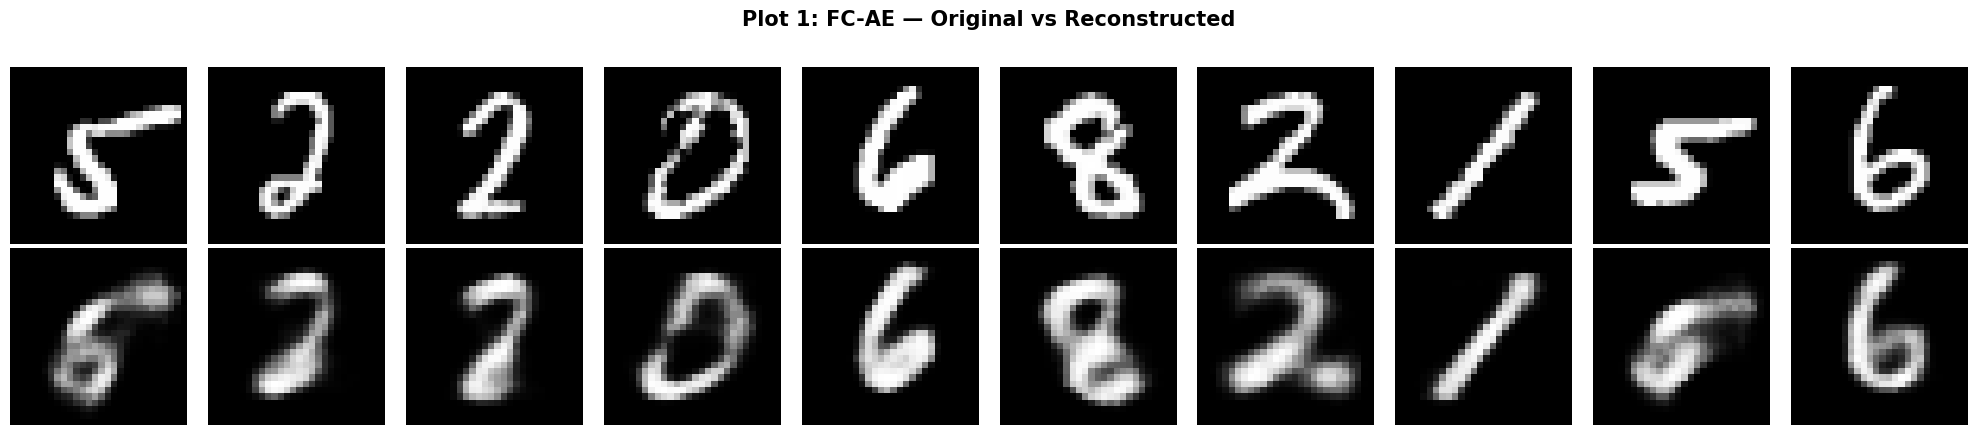

In [8]:
n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(20, 4.5))
idxs = np.arange(n_show)
for i, idx in enumerate(idxs):
    axes[0, i].imshow(x_test_flat[idx].reshape(28,28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(fc_recon[idx].reshape(28,28), cmap='gray')
    axes[1, i].axis('off')
axes[0,0].set_ylabel('Original', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Reconstructed', fontsize=14, fontweight='bold')
fig.suptitle('Plot 1: FC-AE — Original vs Reconstructed', fontweight='bold')
plt.tight_layout()
save_fig(fig, '01_fc_ae_original_vs_reconstructed.png')

**Inference (fill after reviewing output):**
- Digit shape preservation: _[fill after run]_
- Fine-detail loss / blur: _[fill after run]_
- Easy vs difficult samples: _[fill after run]_

### Plot 2 — FC-AE Training vs Validation Loss

[plot saved] 02_fc_ae_train_val_loss.png


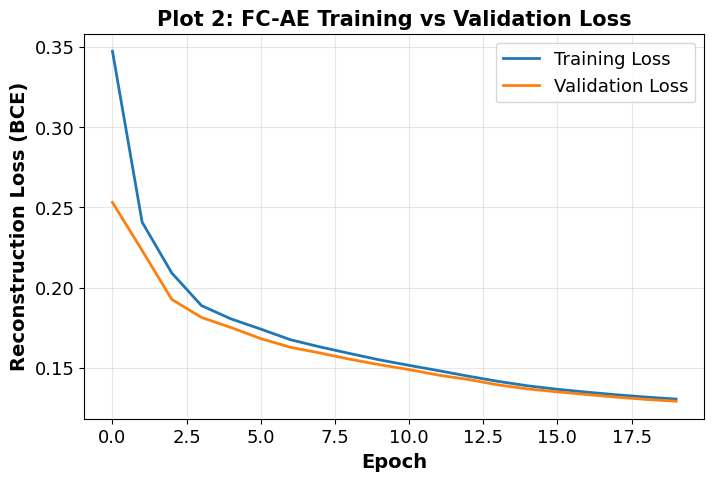

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(fc_history.history['loss'], label='Training Loss', linewidth=2)
ax.plot(fc_history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Reconstruction Loss (BCE)', fontweight='bold')
ax.set_title('Plot 2: FC-AE Training vs Validation Loss', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
save_fig(fig, '02_fc_ae_train_val_loss.png')

**Inference (fill after reviewing output):**
- Convergence: _[fill after run]_
- Overfitting evidence: _[fill after run]_

## 5. Convolutional Autoencoder (Section 10–11)

Baseline uses `UpSampling2D`. A second variant (Additional Exercise 4) replaces upsampling with `Conv2DTranspose` for comparison.

In [10]:
def build_cae(use_transpose=False, name='cae'):
    inp = layers.Input(shape=(28,28,1), name='cae_input')
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    latent = layers.Conv2D(64, 3, activation='relu', padding='same', name='latent_map')(x)

    if use_transpose:
        x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(latent)
        x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
        out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    else:
        x = layers.UpSampling2D(2)(latent)
        x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
        x = layers.UpSampling2D(2)(x)
        out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    model = keras.Model(inp, out, name=name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    return model

cae_baseline = build_cae(use_transpose=False, name='cae_upsampling')
cae_baseline.summary()

Model: "cae_upsampling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cae_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_map (Conv2D)             │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Expect: ~2-3 minutes on Kaggle GPU
t0 = time.time()
cae_history = cae_baseline.fit(
    x_train_img, x_train_img,
    validation_data=(x_test_img, x_test_img),
    epochs=20, batch_size=128, shuffle=True, verbose=1
)
cae_train_time = time.time() - t0
print(f"CAE (UpSampling) training time: {cae_train_time:.1f}s")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.2228 - val_loss: 0.1028
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0924 - val_loss: 0.0839
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0826 - val_loss: 0.0809
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0788 - val_loss: 0.0763
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0765 - val_loss: 0.0743
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0750 - val_loss: 0.0741
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0738 - val_loss: 0.0725
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0731 - val_loss: 0.0714
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0722 - val_loss: 0.0710
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0717 - val_loss: 0.0703
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0712 - val_loss: 0.0698
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0707 - val_l

In [12]:
cae_recon = cae_baseline.predict(x_test_img, verbose=0)
cae_metrics = compute_metrics(x_test_img, cae_recon)
cae_metrics['Parameters'] = count_params(cae_baseline)
cae_metrics['TrainTime_s'] = round(cae_train_time, 1)
print("CAE (UpSampling) test metrics:", cae_metrics)
ALL_METRICS['CAE_UpSampling'] = cae_metrics
save_checkpoint('cae_upsampling', cae_metrics, cae_baseline)

CAE (UpSampling) test metrics: {'MSE': 0.0024648138787597418, 'MAE': 0.015024429187178612, 'SSIM': 0.9751458648933995, 'Parameters': 74497, 'TrainTime_s': 19.5}
[checkpoint saved] cae_upsampling


### Plot 3 — Original vs FC-AE vs CAE Reconstruction

[plot saved] 03_fc_vs_cae_reconstruction.png


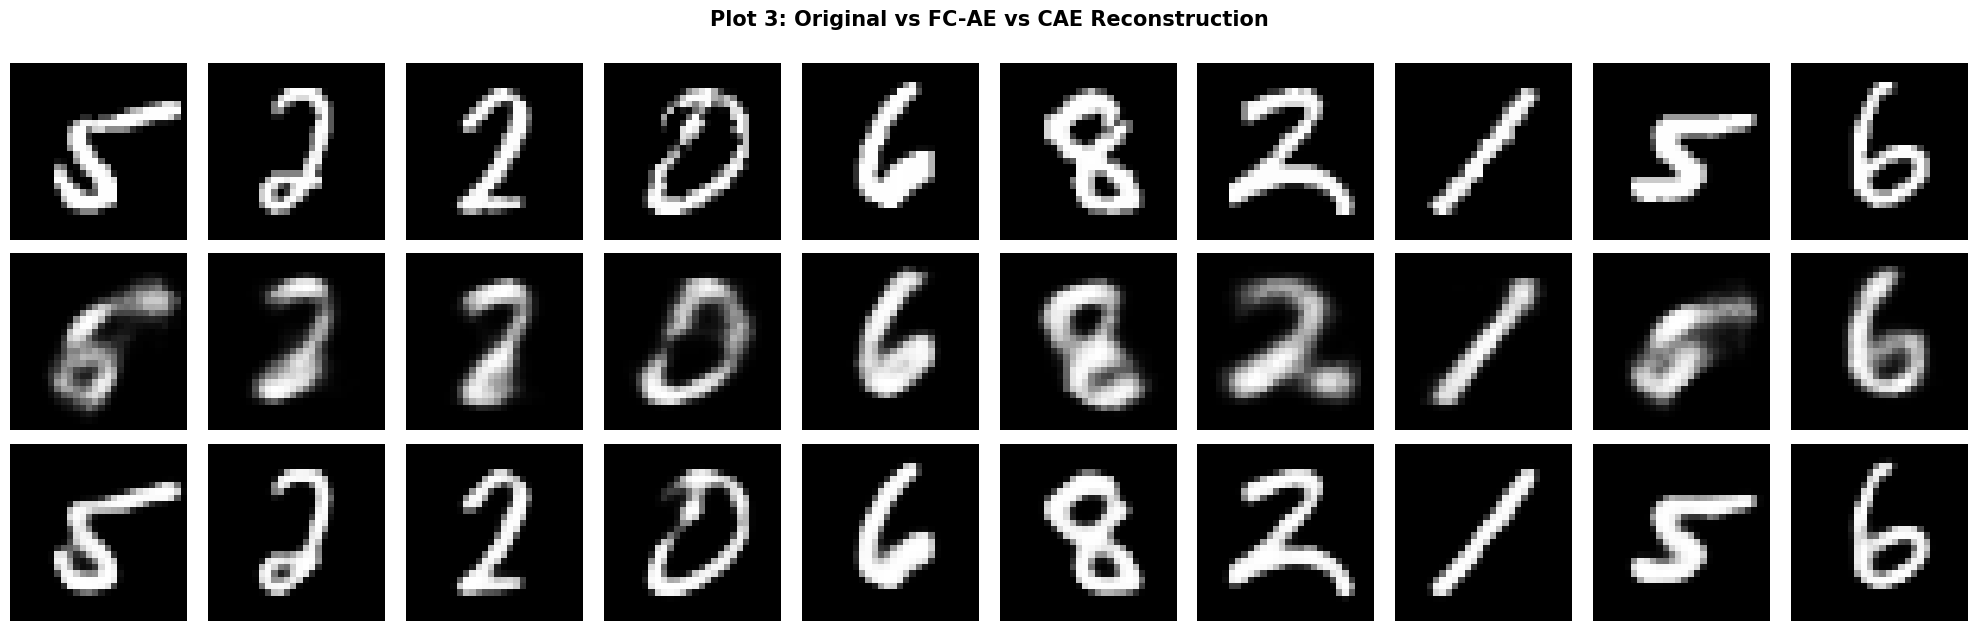

In [13]:
fig, axes = plt.subplots(3, 10, figsize=(20, 6.5))
for i in range(10):
    axes[0,i].imshow(x_test_img[i].reshape(28,28), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(fc_recon[i].reshape(28,28), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(cae_recon[i].reshape(28,28), cmap='gray'); axes[2,i].axis('off')
axes[0,0].set_ylabel('Original', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('FC-AE', fontsize=13, fontweight='bold')
axes[2,0].set_ylabel('CAE', fontsize=13, fontweight='bold')
fig.suptitle('Plot 3: Original vs FC-AE vs CAE Reconstruction', fontweight='bold')
plt.tight_layout()
save_fig(fig, '03_fc_vs_cae_reconstruction.png')

**Inference (fill after reviewing output):**
- Effect of spatial locality / convolution on reconstruction: _[fill after run]_

### Additional Exercise 4 — CAE with `Conv2DTranspose` instead of `UpSampling2D`

Same architecture depth/filters, decoder uses learned transposed convolutions instead of fixed upsampling.

In [14]:
cae_transpose = build_cae(use_transpose=True, name='cae_transpose')
t0 = time.time()
cae_t_history = cae_transpose.fit(
    x_train_img, x_train_img,
    validation_data=(x_test_img, x_test_img),
    epochs=20, batch_size=128, shuffle=True, verbose=1
)
cae_t_train_time = time.time() - t0
print(f"CAE (Transpose) training time: {cae_t_train_time:.1f}s")

cae_t_recon = cae_transpose.predict(x_test_img, verbose=0)
cae_t_metrics = compute_metrics(x_test_img, cae_t_recon)
cae_t_metrics['Parameters'] = count_params(cae_transpose)
cae_t_metrics['TrainTime_s'] = round(cae_t_train_time, 1)
print("CAE (Transpose) test metrics:", cae_t_metrics)
ALL_METRICS['CAE_Transpose'] = cae_t_metrics
save_checkpoint('cae_transpose', cae_t_metrics, cae_transpose)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.3211 - val_loss: 0.1322
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1042 - val_loss: 0.0882
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0849 - val_loss: 0.0836
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0793 - val_loss: 0.0817
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0764 - val_loss: 0.0756
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0745 - val_loss: 0.0729
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0731 - val_loss: 0.0718
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0726 - val_loss: 0.0707
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0715 - val_loss: 0.0701
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0708 - val_loss: 0.0697
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0703 - val_loss: 0.0691
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0699 - val_l

[plot saved] ex4_upsampling_vs_transpose.png


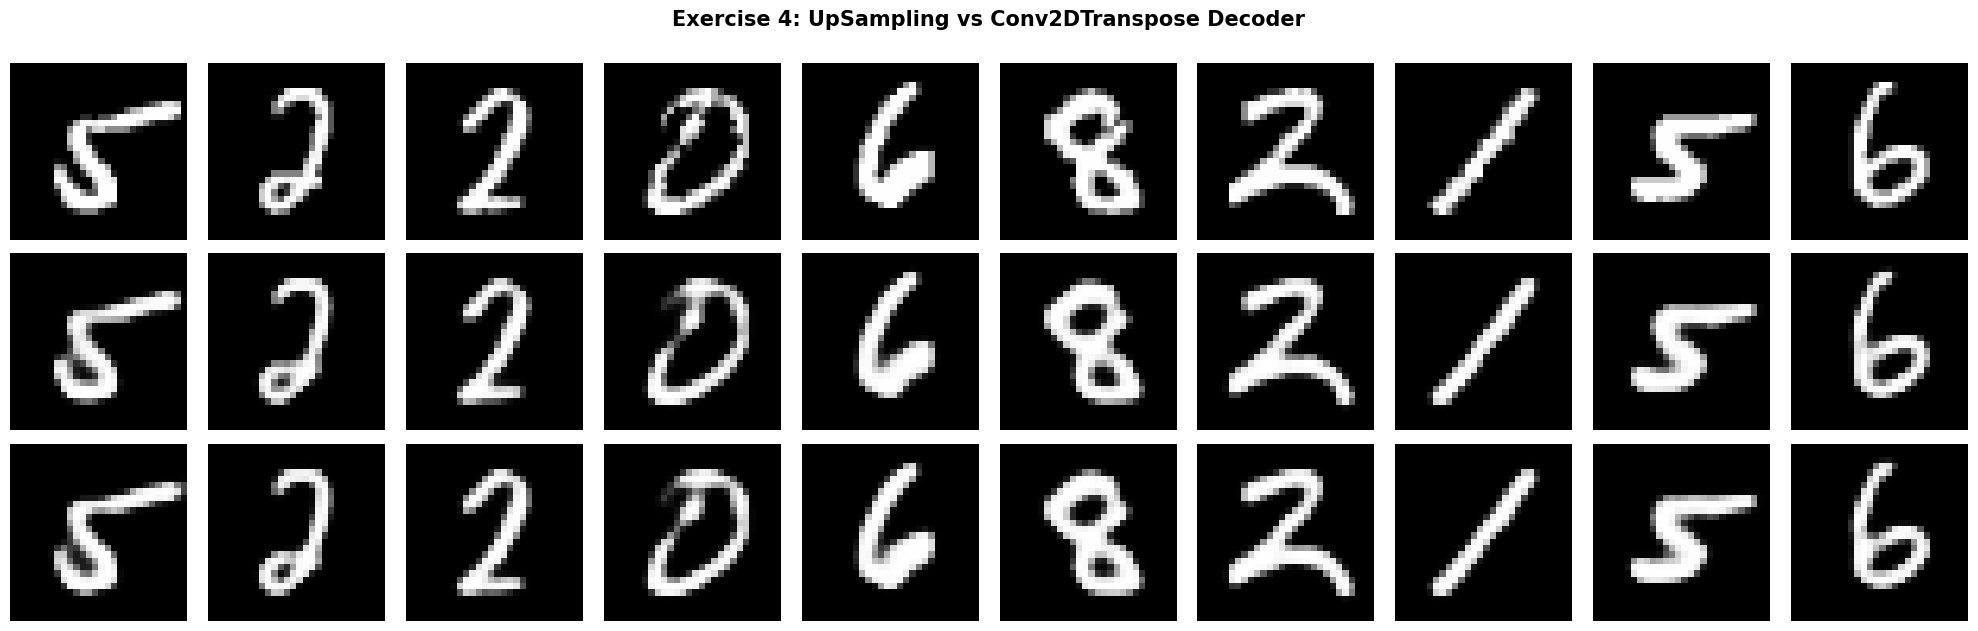

UpSampling  -> MSE=0.00246 MAE=0.01502 SSIM=0.9751 Params=74497
Transpose   -> MSE=0.00224 MAE=0.01402 SSIM=0.9779 Params=83745


In [15]:
fig, axes = plt.subplots(3, 10, figsize=(20, 6.5))
for i in range(10):
    axes[0,i].imshow(x_test_img[i].reshape(28,28), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(cae_recon[i].reshape(28,28), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(cae_t_recon[i].reshape(28,28), cmap='gray'); axes[2,i].axis('off')
axes[0,0].set_ylabel('Original', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('UpSampling', fontsize=13, fontweight='bold')
axes[2,0].set_ylabel('Conv2DTranspose', fontsize=13, fontweight='bold')
fig.suptitle('Exercise 4: UpSampling vs Conv2DTranspose Decoder', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'ex4_upsampling_vs_transpose.png')

cm, ctm = cae_metrics, cae_t_metrics
print(f"UpSampling  -> MSE={cm['MSE']:.5f} MAE={cm['MAE']:.5f} SSIM={cm['SSIM']:.4f} Params={cm['Parameters']}")
print(f"Transpose   -> MSE={ctm['MSE']:.5f} MAE={ctm['MAE']:.5f} SSIM={ctm['SSIM']:.4f} Params={ctm['Parameters']}")

**Inference (fill after reviewing output):**
- UpSampling vs Conv2DTranspose — quality/parameter trade-off: _[fill after run]_

## 6. Denoising Convolutional Autoencoder (Section 12–14)

Trains **6 separate models**: Gaussian noise at σ ∈ {0.1, 0.2, 0.3} and salt-and-pepper noise at p ∈ {0.05, 0.10, 0.20}. Each uses the same CAE architecture (UpSampling variant) as the baseline. Target is always the clean image.

**This is the longest section — expect ~10-15 minutes total for all 6 runs.**

In [16]:
def add_gaussian_noise(images, sigma, seed=SEED):
    rng_local = np.random.RandomState(seed)
    noisy = images + rng_local.normal(0, sigma, images.shape).astype('float32')
    return np.clip(noisy, 0.0, 1.0)

def add_salt_pepper_noise(images, p, seed=SEED):
    rng_local = np.random.RandomState(seed)
    noisy = images.copy()
    mask = rng_local.rand(*images.shape)
    noisy[mask < (p/2)] = 0.0
    noisy[(mask >= (p/2)) & (mask < p)] = 1.0
    return noisy

def build_denoising_cae():
    return build_cae(use_transpose=False, name='denoising_cae')

In [17]:
gaussian_levels = [0.1, 0.2, 0.3]
denoising_results_gaussian = {}
denoising_models_gaussian = {}

for sigma in gaussian_levels:
    print(f"\n=== Training Denoising CAE — Gaussian sigma={sigma} ===")
    x_train_noisy = add_gaussian_noise(x_train_img, sigma)
    x_test_noisy = add_gaussian_noise(x_test_img, sigma)

    model = build_denoising_cae()
    t0 = time.time()
    model.fit(x_train_noisy, x_train_img,
              validation_data=(x_test_noisy, x_test_img),
              epochs=20, batch_size=128, shuffle=True, verbose=1)
    train_time = time.time() - t0

    recon = model.predict(x_test_noisy, verbose=0)
    metrics = compute_metrics(x_test_img, recon)
    metrics['Parameters'] = count_params(model)
    metrics['TrainTime_s'] = round(train_time, 1)
    metrics['NoiseType'] = 'gaussian'
    metrics['NoiseLevel'] = sigma

    denoising_results_gaussian[sigma] = {'metrics': metrics, 'recon': recon, 'noisy': x_test_noisy}
    denoising_models_gaussian[sigma] = model
    print(f"sigma={sigma}: {metrics}")
    save_checkpoint(f'denoise_gaussian_{sigma}', metrics, model)

ALL_METRICS['Denoising_Gaussian'] = {str(k): v['metrics'] for k,v in denoising_results_gaussian.items()}


=== Training Denoising CAE — Gaussian sigma=0.1 ===
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.2312 - val_loss: 0.1059
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0962 - val_loss: 0.0886
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0856 - val_loss: 0.0844
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0814 - val_loss: 0.0787
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0788 - val_loss: 0.0766
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0772 - val_loss: 0.0753
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0760 - val_loss: 0.0742
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0751 - val_loss: 0.0735
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0743 - val_loss: 0.0730
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0737 - val_loss: 0.0724
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0732 - val_loss: 0.0720
Epoch 12/20
79/79 ━━

In [18]:
sp_levels = [0.05, 0.10, 0.20]
denoising_results_sp = {}
denoising_models_sp = {}

for p in sp_levels:
    print(f"\n=== Training Denoising CAE — Salt-and-Pepper p={p} ===")
    x_train_noisy = add_salt_pepper_noise(x_train_img, p)
    x_test_noisy = add_salt_pepper_noise(x_test_img, p)

    model = build_denoising_cae()
    t0 = time.time()
    model.fit(x_train_noisy, x_train_img,
              validation_data=(x_test_noisy, x_test_img),
              epochs=20, batch_size=128, shuffle=True, verbose=1)
    train_time = time.time() - t0

    recon = model.predict(x_test_noisy, verbose=0)
    metrics = compute_metrics(x_test_img, recon)
    metrics['Parameters'] = count_params(model)
    metrics['TrainTime_s'] = round(train_time, 1)
    metrics['NoiseType'] = 'salt_pepper'
    metrics['NoiseLevel'] = p

    denoising_results_sp[p] = {'metrics': metrics, 'recon': recon, 'noisy': x_test_noisy}
    denoising_models_sp[p] = model
    print(f"p={p}: {metrics}")
    save_checkpoint(f'denoise_saltpepper_{p}', metrics, model)

ALL_METRICS['Denoising_SaltPepper'] = {str(k): v['metrics'] for k,v in denoising_results_sp.items()}


=== Training Denoising CAE — Salt-and-Pepper p=0.05 ===
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.2571 - val_loss: 0.1187
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1045 - val_loss: 0.0947
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0912 - val_loss: 0.0866
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0857 - val_loss: 0.0825
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0827 - val_loss: 0.0801
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0807 - val_loss: 0.0785
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0793 - val_loss: 0.0773
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0782 - val_loss: 0.0764
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0773 - val_loss: 0.0757
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0766 - val_loss: 0.0751
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0760 - val_loss: 0.0746
Epoch 12/20
79/7

### Plot 4 — Clean vs Noisy vs Denoised (Gaussian σ=0.2 shown, 10 samples)

[plot saved] 04_denoising_clean_noisy_denoised.png


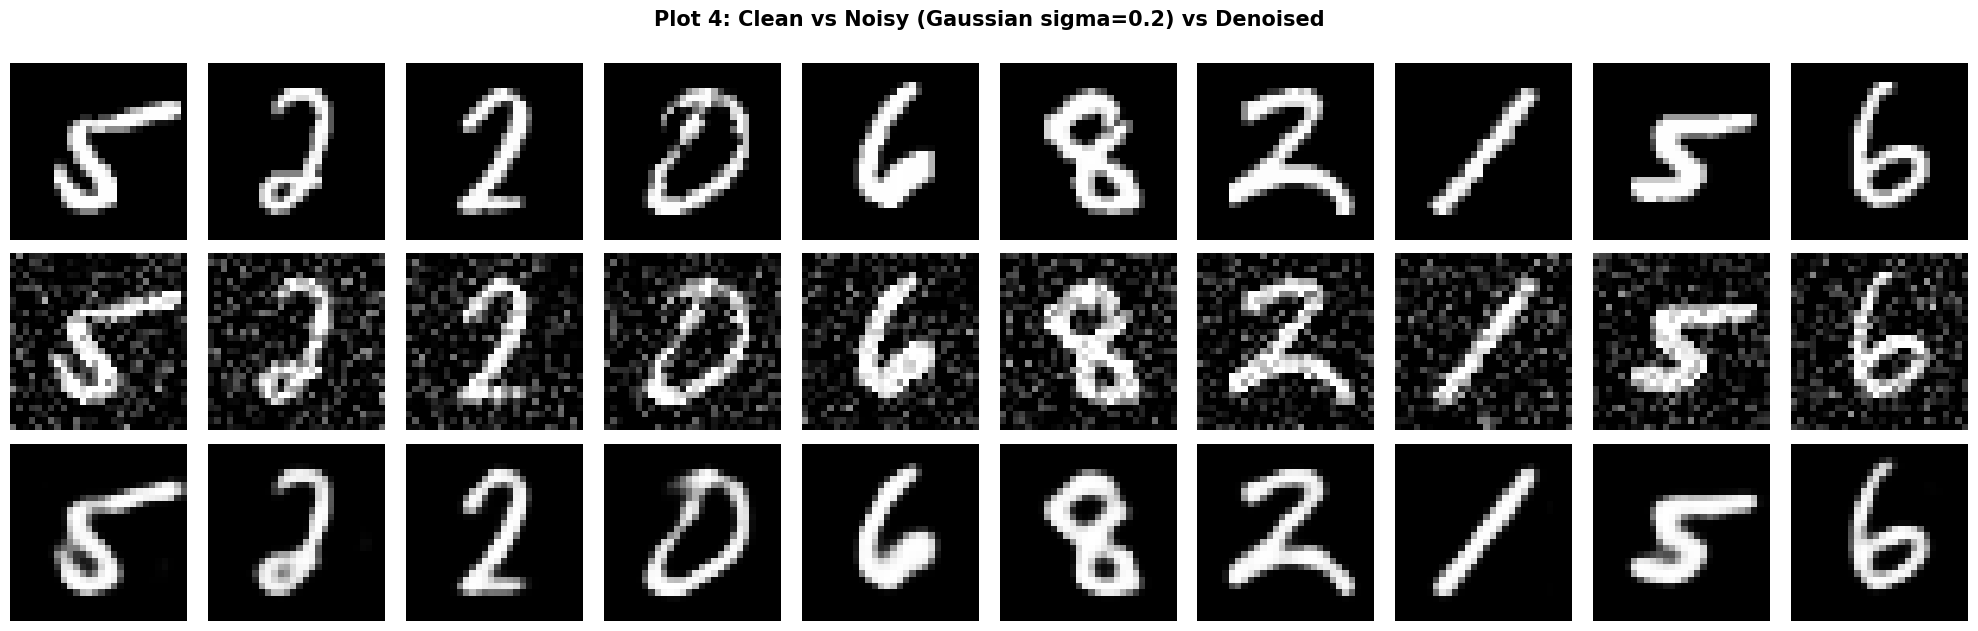

In [19]:
sigma_show = 0.2
recon_show = denoising_results_gaussian[sigma_show]['recon']
noisy_show = denoising_results_gaussian[sigma_show]['noisy']

fig, axes = plt.subplots(3, 10, figsize=(20, 6.5))
for i in range(10):
    axes[0,i].imshow(x_test_img[i].reshape(28,28), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(noisy_show[i].reshape(28,28), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(recon_show[i].reshape(28,28), cmap='gray'); axes[2,i].axis('off')
axes[0,0].set_ylabel('Clean', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Noisy', fontsize=13, fontweight='bold')
axes[2,0].set_ylabel('Denoised', fontsize=13, fontweight='bold')
fig.suptitle(f'Plot 4: Clean vs Noisy (Gaussian sigma={sigma_show}) vs Denoised', fontweight='bold')
plt.tight_layout()
save_fig(fig, '04_denoising_clean_noisy_denoised.png')

### Plot 5 — Noise Level vs Reconstruction Quality (Gaussian)

[plot saved] 05_noise_level_vs_quality.png


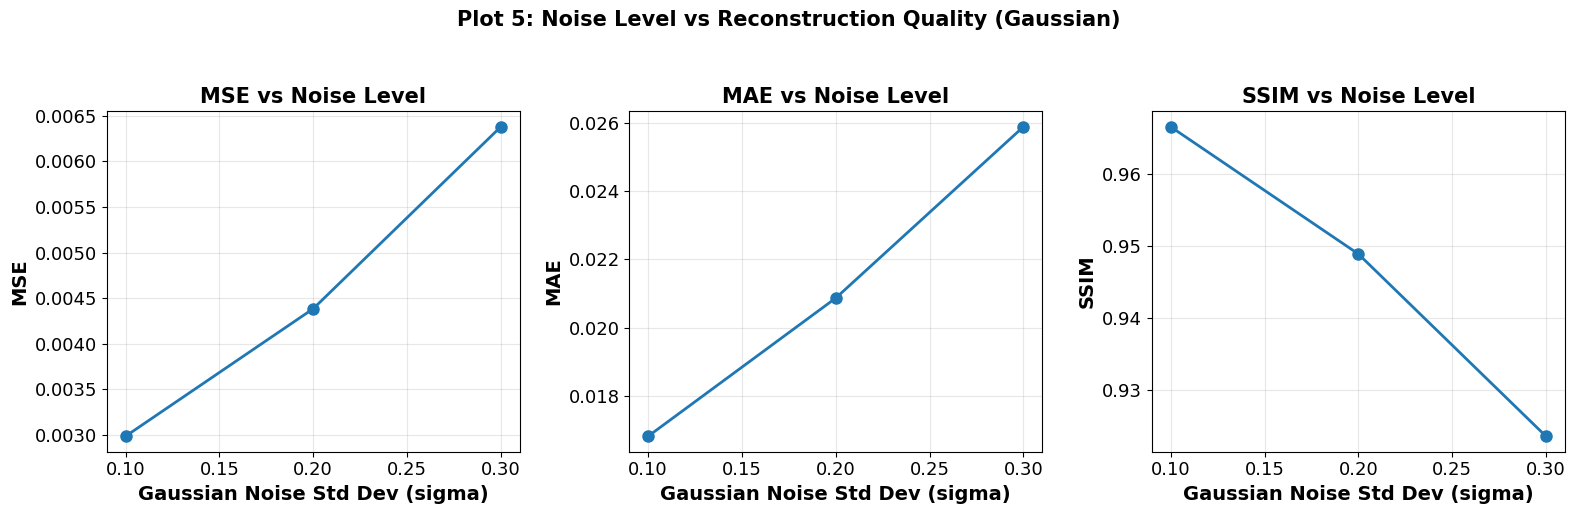

Gaussian Noise Level vs Quality:
  sigma=0.1: MSE=0.00299 MAE=0.01683 SSIM=0.9666
  sigma=0.2: MSE=0.00438 MAE=0.02087 SSIM=0.9489
  sigma=0.3: MSE=0.00638 MAE=0.02588 SSIM=0.9236


In [20]:
fig, axs = plt.subplots(1, 3, figsize=(16,5))
metric_names = ['MSE', 'MAE', 'SSIM']
for ax, mname in zip(axs, metric_names):
    vals = [denoising_results_gaussian[s]['metrics'][mname] for s in gaussian_levels]
    ax.plot(gaussian_levels, vals, marker='o', linewidth=2, markersize=8)
    ax.set_xlabel('Gaussian Noise Std Dev (sigma)', fontweight='bold')
    ax.set_ylabel(mname, fontweight='bold')
    ax.set_title(f'{mname} vs Noise Level', fontweight='bold')
    ax.grid(alpha=0.3)
fig.suptitle('Plot 5: Noise Level vs Reconstruction Quality (Gaussian)', fontweight='bold', y=1.03)
plt.tight_layout()
save_fig(fig, '05_noise_level_vs_quality.png')

print("Gaussian Noise Level vs Quality:")
for s in gaussian_levels:
    m = denoising_results_gaussian[s]['metrics']
    print(f"  sigma={s}: MSE={m['MSE']:.5f} MAE={m['MAE']:.5f} SSIM={m['SSIM']:.4f}")

**Inference (fill after reviewing output):**
- Effect of increasing corruption on reconstruction quality: _[fill after run]_
- Does the model recover major structure: _[fill after run]_

### Additional Exercise 2 & 3 — Gaussian vs Salt-and-Pepper Noise Comparison (Same Architecture)

Compares both noise families directly at matched "moderate" severity, and reports SSIM across two levels per exercise 3.

[plot saved] ex2_gaussian_vs_saltpepper.png


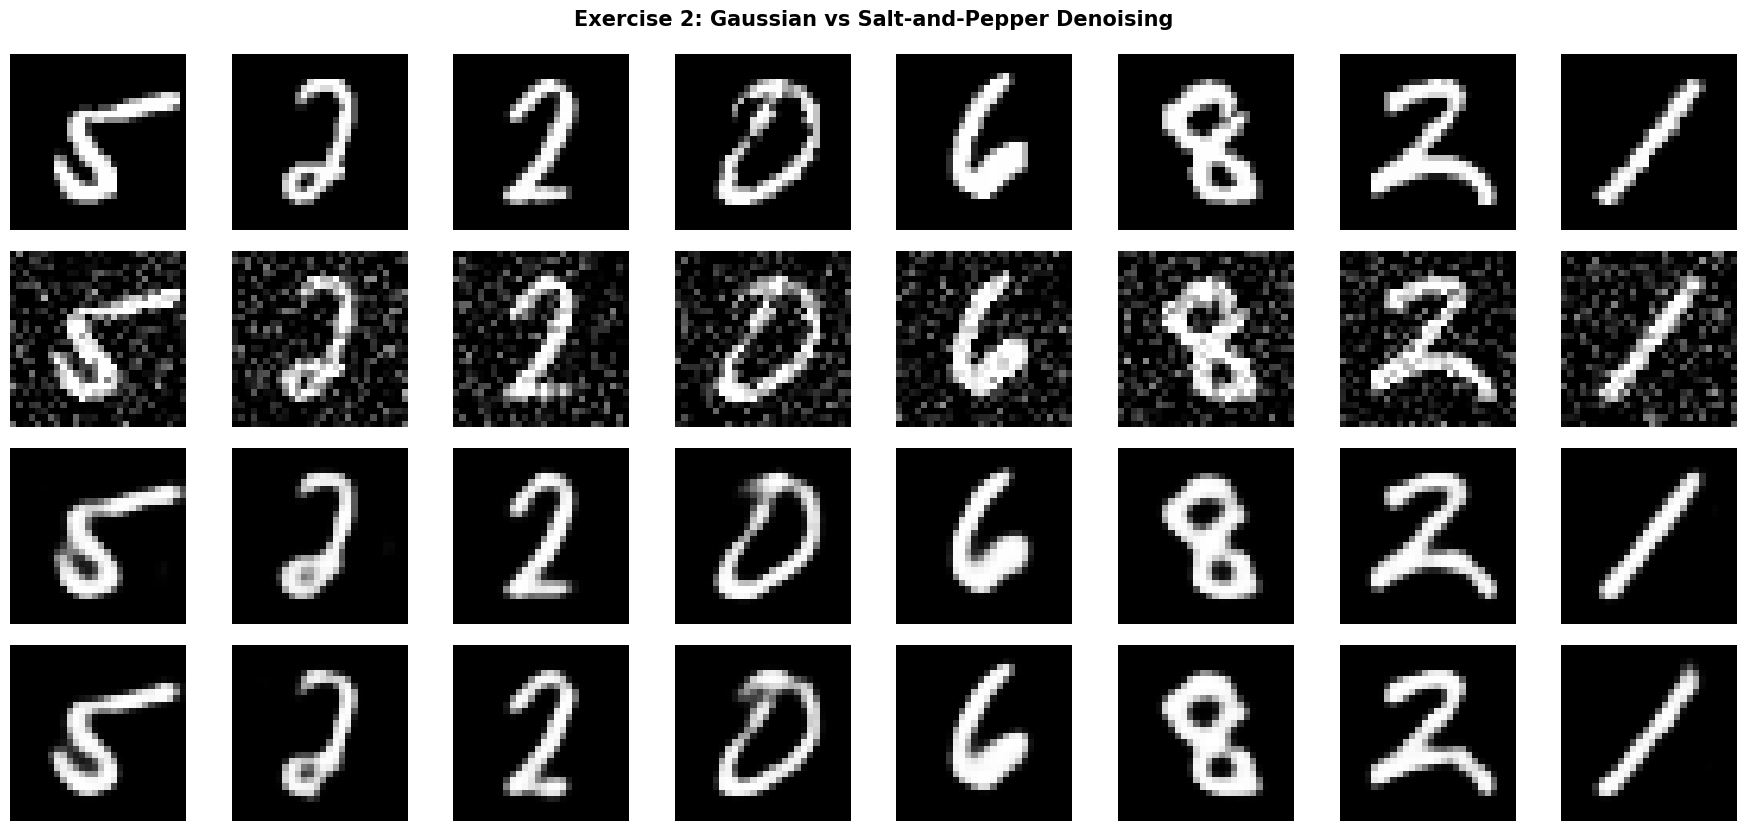

SSIM comparison across noise types (Exercise 3):
  Gaussian sigma=0.1: SSIM=0.9666
  Gaussian sigma=0.2: SSIM=0.9489
  Gaussian sigma=0.3: SSIM=0.9236
  Salt-Pepper p=0.05: SSIM=0.9598
  Salt-Pepper p=0.1: SSIM=0.9497
  Salt-Pepper p=0.2: SSIM=0.9179


In [21]:
fig, axes = plt.subplots(4, 8, figsize=(18, 8.5))
show_idxs = np.arange(8)
g_sigma, sp_p = 0.2, 0.10

for i, idx in enumerate(show_idxs):
    axes[0,i].imshow(x_test_img[idx].reshape(28,28), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(denoising_results_gaussian[g_sigma]['noisy'][idx].reshape(28,28), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(denoising_results_gaussian[g_sigma]['recon'][idx].reshape(28,28), cmap='gray'); axes[2,i].axis('off')
    axes[3,i].imshow(denoising_results_sp[sp_p]['recon'][idx].reshape(28,28), cmap='gray'); axes[3,i].axis('off')
axes[0,0].set_ylabel('Clean', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel(f'Gaussian noisy\n(sigma={g_sigma})', fontsize=11, fontweight='bold')
axes[2,0].set_ylabel('Gaussian\ndenoised', fontsize=11, fontweight='bold')
axes[3,0].set_ylabel(f'Salt-Pepper\ndenoised (p={sp_p})', fontsize=11, fontweight='bold')
fig.suptitle('Exercise 2: Gaussian vs Salt-and-Pepper Denoising', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'ex2_gaussian_vs_saltpepper.png')

print("SSIM comparison across noise types (Exercise 3):")
for s in gaussian_levels:
    m = denoising_results_gaussian[s]['metrics']
    print(f"  Gaussian sigma={s}: SSIM={m['SSIM']:.4f}")
for p in sp_levels:
    m = denoising_results_sp[p]['metrics']
    print(f"  Salt-Pepper p={p}: SSIM={m['SSIM']:.4f}")

**Inference (fill after reviewing output):**
- Which noise type is harder to denoise, and why: _[fill after run]_

## 7. Variational Autoencoder (Section 15–20)

Latent dimension 2 (as required, for visualization). Encoder outputs (μ, log σ²); reparameterization trick samples z = μ + σ⊙ε. Decoder reconstructs from z. Loss = reconstruction (BCE) + KL divergence.

In [22]:
class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + sigma * epsilon"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim), seed=SEED)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def build_vae_encoder(latent_dim):
    inp = layers.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(inp)
    x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    return keras.Model(inp, [z_mean, z_log_var, z], name=f'vae_encoder_dim{latent_dim}')

def build_vae_decoder(latent_dim):
    inp = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7*7*64, activation='relu')(inp)
    x = layers.Reshape((7,7,64))(x)
    x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
    out = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)
    return keras.Model(inp, out, name=f'vae_decoder_dim{latent_dim}')


class VAE(keras.Model):
    def __init__(self, latent_dim=2, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = build_vae_encoder(latent_dim)
        self.decoder = build_vae_decoder(latent_dim)
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name='total_loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(x, reconstruction), axis=(1,2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {'loss': self.total_loss_tracker.result(),
                'recon_loss': self.recon_loss_tracker.result(),
                'kl_loss': self.kl_loss_tracker.result()}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(x, reconstruction), axis=(1,2))
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return {'loss': total_loss, 'recon_loss': recon_loss, 'kl_loss': kl_loss}

In [23]:
vae2 = VAE(latent_dim=2, beta=1.0)
vae2.compile(optimizer=keras.optimizers.Adam(1e-3))

# Expect: ~4-5 minutes on Kaggle GPU
t0 = time.time()
vae2_history = vae2.fit(
    x_train_img, x_train_img,
    validation_data=(x_test_img, x_test_img),
    epochs=20, batch_size=128, shuffle=True, verbose=1
)
vae2_train_time = time.time() - t0
print(f"VAE (latent=2) training time: {vae2_train_time:.1f}s")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - kl_loss: 1.8239 - loss: 285.4600 - recon_loss: 283.6360 - val_kl_loss: 0.5390 - val_loss: 212.4379 - val_recon_loss: 211.8989
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 1.8912 - loss: 204.7247 - recon_loss: 202.8336 - val_kl_loss: 2.7670 - val_loss: 194.1765 - val_recon_loss: 191.4095
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 2.3720 - loss: 194.3958 - recon_loss: 192.0239 - val_kl_loss: 2.4016 - val_loss: 188.7857 - val_recon_loss: 186.3841
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 2.3158 - loss: 191.2359 - recon_loss: 188.9201 - val_kl_loss: 2.5087 - val_loss: 185.9002 - val_recon_loss: 183.3916
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 2.9358 - loss: 186.7943 - recon_loss: 183.8584 - val_kl_loss: 3.6877 - val_loss: 178.3638 - val_recon_loss: 174.6761
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.9184 - loss: 178.1966 - recon_loss: 174.2783 

In [24]:
z_mean_test, z_log_var_test, z_test = vae2.encoder.predict(x_test_img, verbose=0)
vae2_recon = vae2.decoder.predict(z_test, verbose=0)

vae2_metrics = compute_metrics(x_test_img, vae2_recon)
final_recon_loss = vae2_history.history['val_recon_loss'][-1]
final_kl_loss = vae2_history.history['val_kl_loss'][-1]
final_total_loss = vae2_history.history['val_loss'][-1]

vae2_metrics.update({
    'ReconstructionLoss': float(final_recon_loss),
    'KLLoss': float(final_kl_loss),
    'TotalLoss': float(final_total_loss),
    'Parameters': count_params(vae2.encoder) + count_params(vae2.decoder),
    'TrainTime_s': round(vae2_train_time, 1)
})
print("VAE (latent=2) metrics:", vae2_metrics)
ALL_METRICS['VAE_latent2'] = vae2_metrics
save_checkpoint('vae_latent2', vae2_metrics, vae2)

VAE (latent=2) metrics: {'MSE': 0.0447460301220417, 'MAE': 0.10481655597686768, 'SSIM': 0.5006957301807985, 'ReconstructionLoss': 150.06326293945312, 'KLLoss': 5.43938684463501, 'TotalLoss': 155.50265502929688, 'Parameters': 284933, 'TrainTime_s': 21.7}
[checkpoint saved] vae_latent2


### Plot 9 (training curve) — VAE Training vs Validation Loss

[plot saved] 09_vae_train_val_loss.png


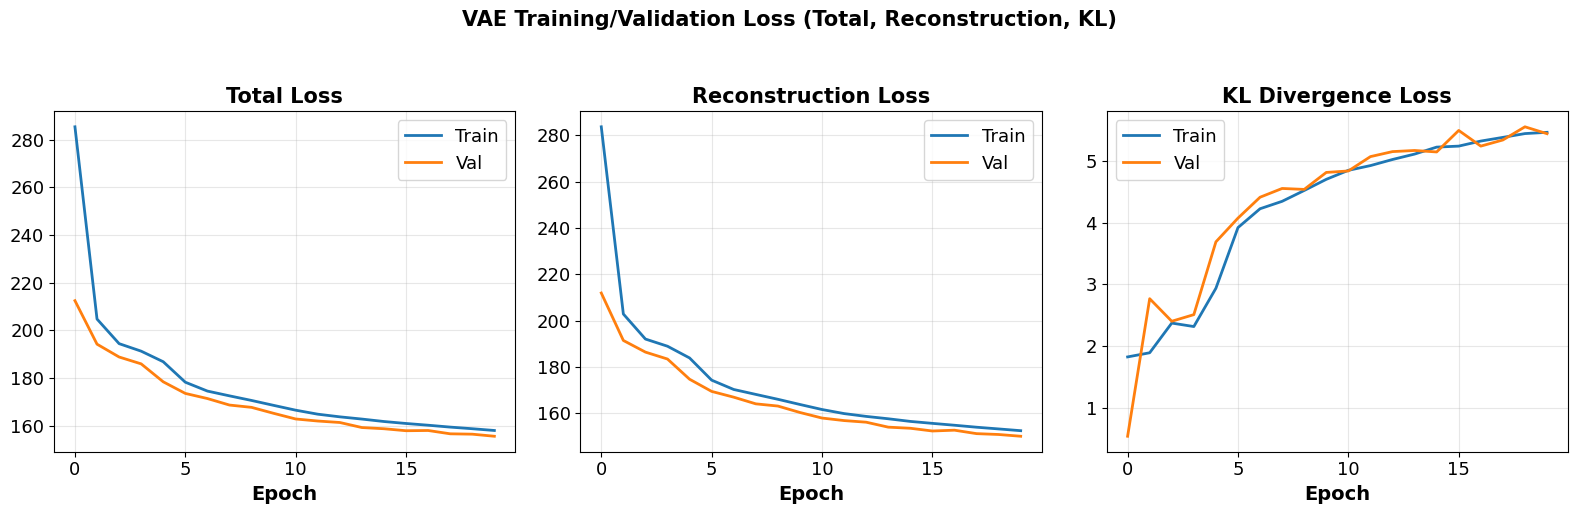

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(16,5))
axs[0].plot(vae2_history.history['loss'], label='Train', linewidth=2)
axs[0].plot(vae2_history.history['val_loss'], label='Val', linewidth=2)
axs[0].set_title('Total Loss', fontweight='bold'); axs[0].set_xlabel('Epoch', fontweight='bold'); axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(vae2_history.history['recon_loss'], label='Train', linewidth=2)
axs[1].plot(vae2_history.history['val_recon_loss'], label='Val', linewidth=2)
axs[1].set_title('Reconstruction Loss', fontweight='bold'); axs[1].set_xlabel('Epoch', fontweight='bold'); axs[1].legend(); axs[1].grid(alpha=0.3)

axs[2].plot(vae2_history.history['kl_loss'], label='Train', linewidth=2)
axs[2].plot(vae2_history.history['val_kl_loss'], label='Val', linewidth=2)
axs[2].set_title('KL Divergence Loss', fontweight='bold'); axs[2].set_xlabel('Epoch', fontweight='bold'); axs[2].legend(); axs[2].grid(alpha=0.3)

fig.suptitle('VAE Training/Validation Loss (Total, Reconstruction, KL)', fontweight='bold', y=1.03)
plt.tight_layout()
save_fig(fig, '09_vae_train_val_loss.png')

### Plot 6 — VAE Latent Space Visualization (2D, colored by digit)

[plot saved] 06_vae_latent_space.png


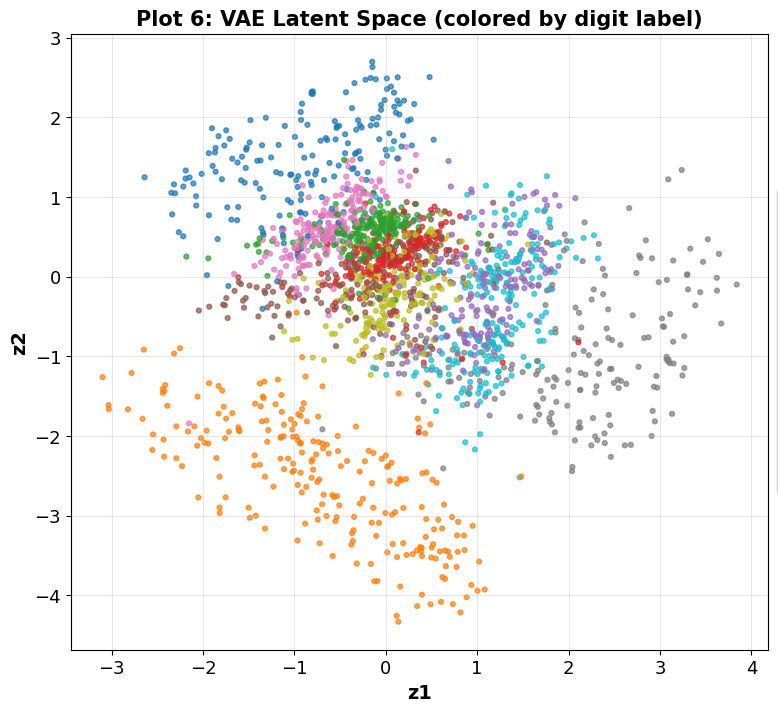

In [26]:
fig, ax = plt.subplots(figsize=(9,8))
scatter = ax.scatter(z_mean_test[:,0], z_mean_test[:,1], c=y_test, cmap='tab10', s=12, alpha=0.7)
ax.set_xlabel('z1', fontweight='bold')
ax.set_ylabel('z2', fontweight='bold')
ax.set_title('Plot 6: VAE Latent Space (colored by digit label)', fontweight='bold')
legend1 = ax.legend(*scatter.legend_elements(), title='Digit', loc='center left', bbox_to_anchor=(1,0.5))
ax.add_artist(legend1)
ax.grid(alpha=0.3)
save_fig(fig, '06_vae_latent_space.png')

**Inference (fill after reviewing output):**
- Do same-digit samples cluster together: _[fill after run]_
- Overlap between digits: _[fill after run]_

### Plot 7 — Randomly Generated VAE Images (25 samples)

[plot saved] 07_vae_generated_samples.png


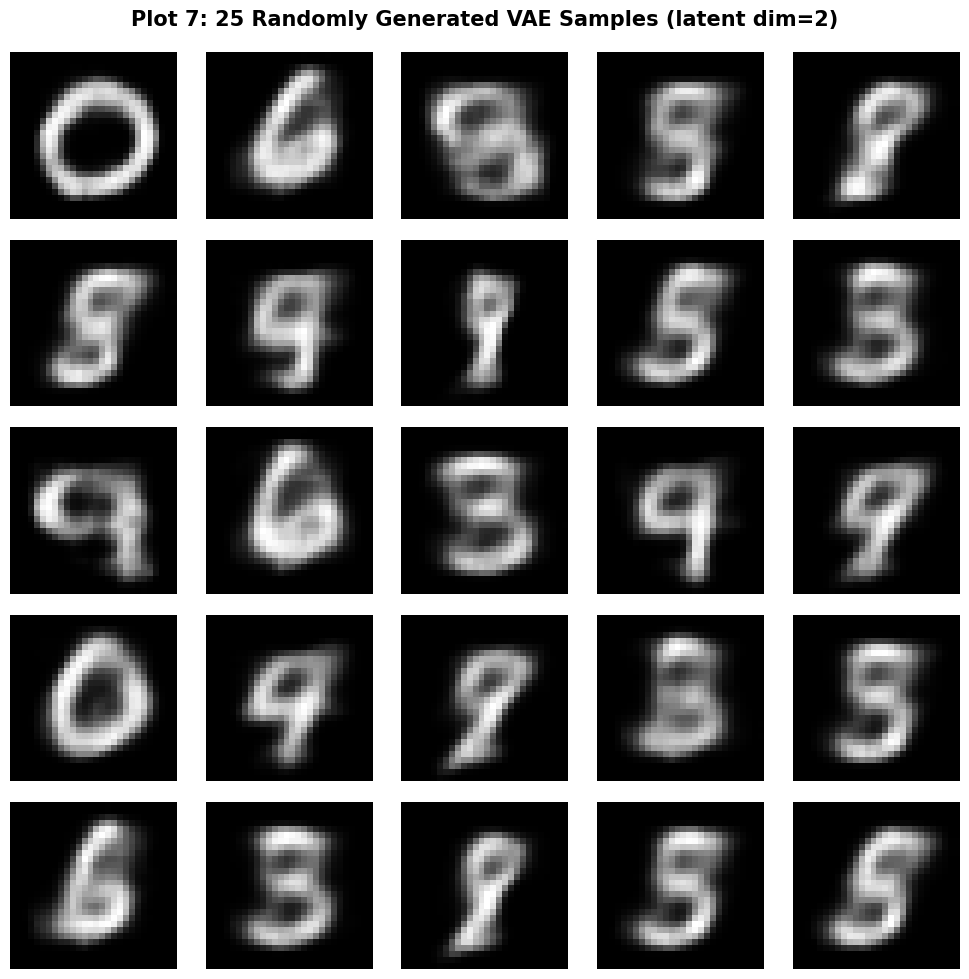

In [27]:
gen_rng = np.random.RandomState(SEED)
z_random = gen_rng.normal(0, 1, size=(25, 2)).astype('float32')
generated = vae2.decoder.predict(z_random, verbose=0)

fig, axes = plt.subplots(5, 5, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].reshape(28,28), cmap='gray')
    ax.axis('off')
fig.suptitle('Plot 7: 25 Randomly Generated VAE Samples (latent dim=2)', fontweight='bold')
plt.tight_layout()
save_fig(fig, '07_vae_generated_samples.png')

**Inference (fill after reviewing output):**
- Do samples resemble real digits: _[fill after run]_
- Recognizability / diversity / ambiguous samples: _[fill after run]_

### Plot 8 — Latent Space Interpolation

[plot saved] 08_vae_latent_interpolation.png


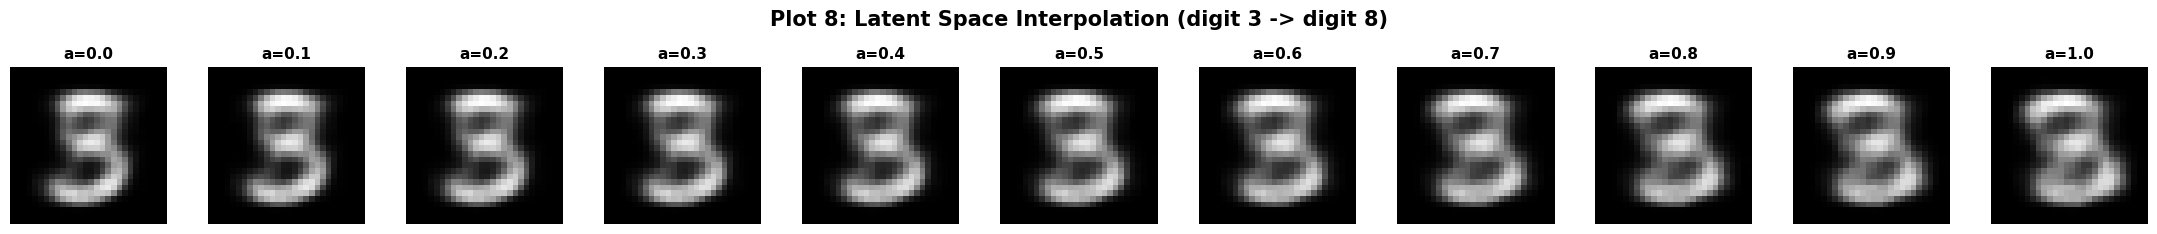

In [28]:
# Pick two test points from different digit classes as zA, zB
digit_a, digit_b = 3, 8  # can be changed
idx_a = np.where(y_test == digit_a)[0][0]
idx_b = np.where(y_test == digit_b)[0][0]
zA = z_mean_test[idx_a]
zB = z_mean_test[idx_b]

alphas = np.linspace(0, 1, 11)
z_interp = np.array([(1-a)*zA + a*zB for a in alphas]).astype('float32')
decoded_interp = vae2.decoder.predict(z_interp, verbose=0)

fig, axes = plt.subplots(1, 11, figsize=(22,2.4))
for i, ax in enumerate(axes):
    ax.imshow(decoded_interp[i].reshape(28,28), cmap='gray')
    ax.set_title(f'a={alphas[i]:.1f}', fontsize=11, fontweight='bold')
    ax.axis('off')
fig.suptitle(f'Plot 8: Latent Space Interpolation (digit {digit_a} -> digit {digit_b})', fontweight='bold')
plt.tight_layout()
save_fig(fig, '08_vae_latent_interpolation.png')

**Inference (fill after reviewing output):**
- Smoothness of transition between digits: _[fill after run]_

## 8. Reconstruction Comparison Across Models, Error Distribution, High-Error Samples (Section 21, 23, 24)

Uses the FC-AE (baseline, latent=16), CAE (UpSampling baseline), Denoising CAE (Gaussian σ=0.2 run), and VAE (latent=2) already trained above.

In [29]:
comparison_table = {
    'FC_AE': fc_metrics,
    'CAE': cae_metrics,
    'Denoising_CAE (Gaussian sigma=0.2)': denoising_results_gaussian[0.2]['metrics'],
    'VAE (latent=2)': vae2_metrics,
}
print("=== Section 21: Reconstruction Comparison Across Models ===")
for name, m in comparison_table.items():
    print(f"{name}: MSE={m['MSE']:.5f} MAE={m['MAE']:.5f} SSIM={m['SSIM']:.4f} Params={m['Parameters']}")
ALL_METRICS['CrossModelComparison'] = comparison_table

=== Section 21: Reconstruction Comparison Across Models ===
FC_AE: MSE=0.02252 MAE=0.05972 SSIM=0.7452 Params=211040
CAE: MSE=0.00246 MAE=0.01502 SSIM=0.9751 Params=74497
Denoising_CAE (Gaussian sigma=0.2): MSE=0.00438 MAE=0.02087 SSIM=0.9489 Params=74497
VAE (latent=2): MSE=0.04475 MAE=0.10482 SSIM=0.5007 Params=284933


### Plot 9 (Section 22 item 10) — Distribution of Reconstruction Errors (Test Set, FC-AE)

[plot saved] 09b_reconstruction_error_distribution.png


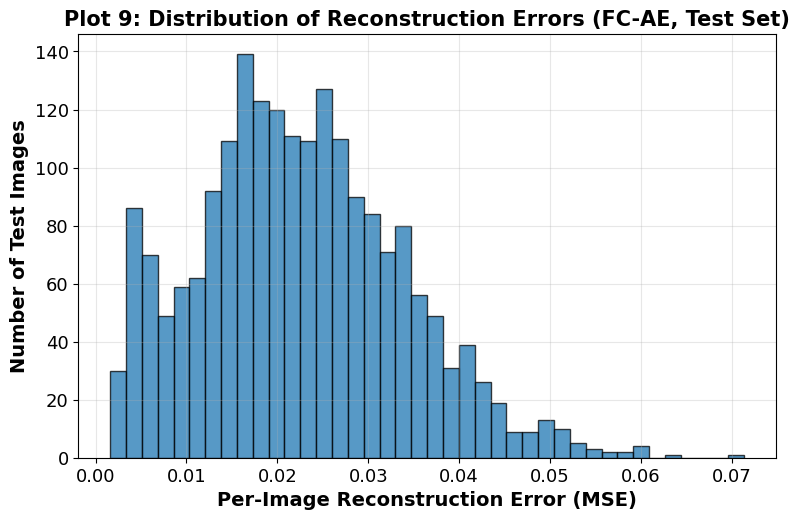

Error range: 0.00160 - 0.07135
Mean: 0.02252  Std: 0.01124


In [30]:
per_image_error_fc = np.mean((x_test_flat - fc_recon) ** 2, axis=1)

fig, ax = plt.subplots(figsize=(9,5.5))
ax.hist(per_image_error_fc, bins=40, edgecolor='black', alpha=0.75)
ax.set_xlabel('Per-Image Reconstruction Error (MSE)', fontweight='bold')
ax.set_ylabel('Number of Test Images', fontweight='bold')
ax.set_title('Plot 9: Distribution of Reconstruction Errors (FC-AE, Test Set)', fontweight='bold')
ax.grid(alpha=0.3)
save_fig(fig, '09b_reconstruction_error_distribution.png')

print(f"Error range: {per_image_error_fc.min():.5f} - {per_image_error_fc.max():.5f}")
print(f"Mean: {per_image_error_fc.mean():.5f}  Std: {per_image_error_fc.std():.5f}")

**Inference (fill after reviewing output):**
- Typical error range: _[fill after run]_
- Concentrated vs spread out: _[fill after run]_

### Section 24 — Five Highest-Error Test Images (FC-AE)

[plot saved] 10_high_error_samples.png


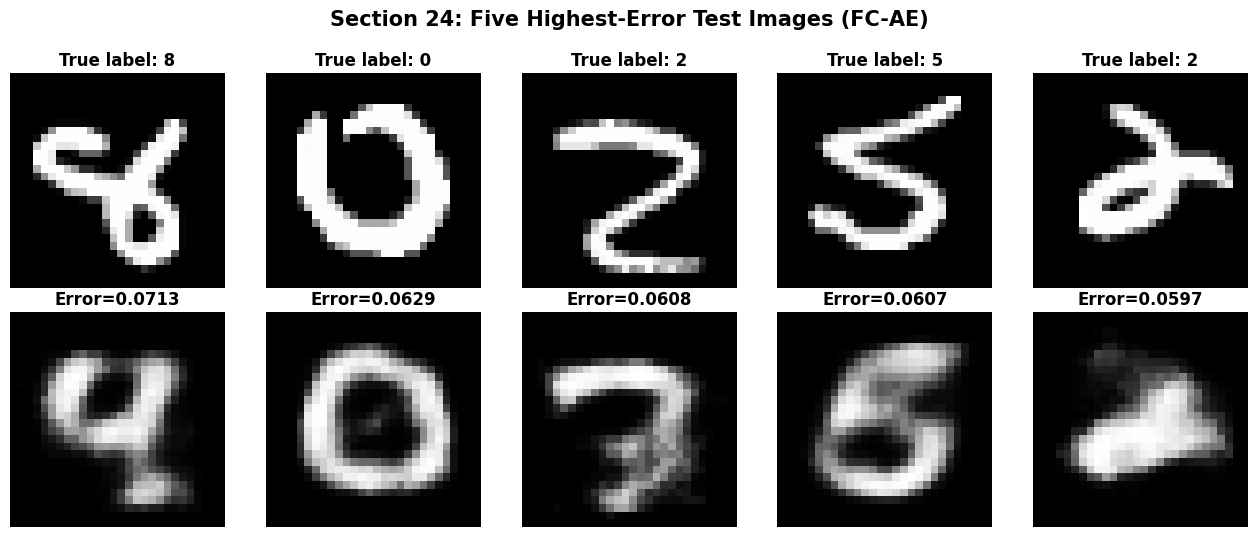

Top-5 highest error samples (idx, true label, error):
  idx=610, label=8, error=0.07135
  idx=724, label=0, error=0.06287
  idx=655, label=2, error=0.06080
  idx=128, label=5, error=0.06074
  idx=1884, label=2, error=0.05969


In [31]:
top5_idx = np.argsort(per_image_error_fc)[-5:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(13,5.5))
for i, idx in enumerate(top5_idx):
    axes[0,i].imshow(x_test_flat[idx].reshape(28,28), cmap='gray')
    axes[0,i].set_title(f'True label: {y_test[idx]}', fontsize=12, fontweight='bold')
    axes[0,i].axis('off')
    axes[1,i].imshow(fc_recon[idx].reshape(28,28), cmap='gray')
    axes[1,i].set_title(f'Error={per_image_error_fc[idx]:.4f}', fontsize=12, fontweight='bold')
    axes[1,i].axis('off')
axes[0,0].set_ylabel('Original', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Reconstruction', fontsize=13, fontweight='bold')
fig.suptitle('Section 24: Five Highest-Error Test Images (FC-AE)', fontweight='bold')
plt.tight_layout()
save_fig(fig, '10_high_error_samples.png')

print("Top-5 highest error samples (idx, true label, error):")
for idx in top5_idx:
    print(f"  idx={idx}, label={y_test[idx]}, error={per_image_error_fc[idx]:.5f}")

**Inference (fill after reviewing output):**
- Why these images are difficult to reconstruct: _[fill after run]_

## 9. Additional Latent-Dimension Study — FC-AE (Section 27)

Repeats the FC-AE with latent dims {2, 8, 16, 32}. The dim=16 result reuses the baseline FC-AE trained above; 2, 8, 32 are trained fresh.

**Expect ~4-6 minutes for the 3 new runs.**

In [32]:
fc_latent_dims = [2, 8, 16, 32]
fc_dim_results = {16: {'metrics': fc_metrics, 'model': fc_ae}}

for dim in [d for d in fc_latent_dims if d != 16]:
    print(f"\n=== Training FC-AE, latent_dim={dim} ===")
    model, encoder = build_fc_autoencoder(latent_dim=dim)
    t0 = time.time()
    model.fit(x_train_flat, x_train_flat,
              validation_data=(x_test_flat, x_test_flat),
              epochs=20, batch_size=128, shuffle=True, verbose=1)
    train_time = time.time() - t0

    recon = model.predict(x_test_flat, verbose=0)
    metrics = compute_metrics(x_test_flat, recon)
    metrics['Parameters'] = count_params(model)
    metrics['TrainTime_s'] = round(train_time, 1)

    fc_dim_results[dim] = {'metrics': metrics, 'model': model}
    print(f"dim={dim}: {metrics}")
    save_checkpoint(f'fc_ae_latentdim_{dim}', metrics, model)

ALL_METRICS['FC_AE_LatentDimSweep'] = {str(d): fc_dim_results[d]['metrics'] for d in fc_latent_dims}


=== Training FC-AE, latent_dim=2 ===
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.3552 - val_loss: 0.2596
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2509 - val_loss: 0.2427
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2408 - val_loss: 0.2355
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2352 - val_loss: 0.2315
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2315 - val_loss: 0.2281
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2285 - val_loss: 0.2251
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2256 - val_loss: 0.2221
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2228 - val_loss: 0.2194
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2206 - val_loss: 0.2173
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2187 - val_loss: 0.2156
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2171 - val_loss: 0.2139
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━

### Plot 10 — FC-AE Latent Dimension vs Reconstruction MSE

[plot saved] 11_fc_ae_latent_dim_sweep.png


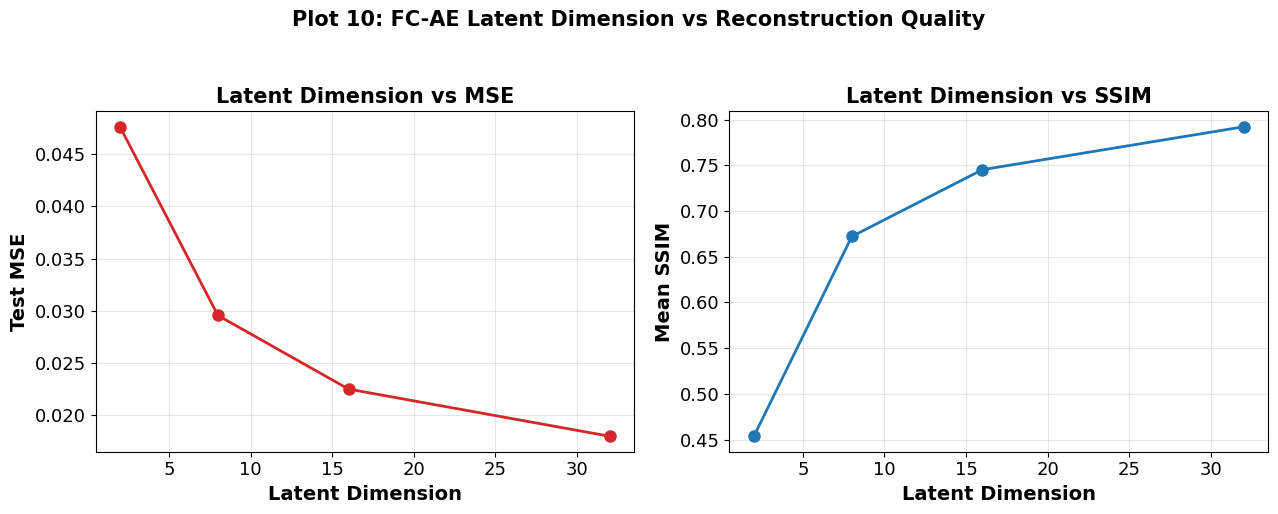

FC-AE Latent Dimension Sweep:
  dim=2: MSE=0.04759 SSIM=0.4537 Params=210130
  dim=8: MSE=0.02956 SSIM=0.6722 Params=210520
  dim=16: MSE=0.02252 SSIM=0.7452 Params=211040
  dim=32: MSE=0.01802 SSIM=0.7921 Params=212080


In [33]:
fig, axs = plt.subplots(1,2, figsize=(13,5))
mse_vals = [fc_dim_results[d]['metrics']['MSE'] for d in fc_latent_dims]
ssim_vals = [fc_dim_results[d]['metrics']['SSIM'] for d in fc_latent_dims]

axs[0].plot(fc_latent_dims, mse_vals, marker='o', linewidth=2, markersize=8, color='tab:red')
axs[0].set_xlabel('Latent Dimension', fontweight='bold')
axs[0].set_ylabel('Test MSE', fontweight='bold')
axs[0].set_title('Latent Dimension vs MSE', fontweight='bold')
axs[0].grid(alpha=0.3)

axs[1].plot(fc_latent_dims, ssim_vals, marker='o', linewidth=2, markersize=8, color='tab:blue')
axs[1].set_xlabel('Latent Dimension', fontweight='bold')
axs[1].set_ylabel('Mean SSIM', fontweight='bold')
axs[1].set_title('Latent Dimension vs SSIM', fontweight='bold')
axs[1].grid(alpha=0.3)

fig.suptitle('Plot 10: FC-AE Latent Dimension vs Reconstruction Quality', fontweight='bold', y=1.03)
plt.tight_layout()
save_fig(fig, '11_fc_ae_latent_dim_sweep.png')

print("FC-AE Latent Dimension Sweep:")
for d in fc_latent_dims:
    m = fc_dim_results[d]['metrics']
    print(f"  dim={d}: MSE={m['MSE']:.5f} SSIM={m['SSIM']:.4f} Params={m['Parameters']}")

**Inference (fill after reviewing output):**
- Compression vs reconstruction quality trade-off: _[fill after run]_

## 10. Additional Exercise 1 — CAE with Latent Dims {4, 8, 16, 32}

Varies the number of filters in the CAE's bottleneck Conv2D layer (proxy for latent capacity in a convolutional setting) at 4, 8, 16, 32 channels, holding architecture depth fixed.

**Expect ~8-10 minutes for these 4 runs.**

In [34]:
def build_cae_variable_latent(latent_channels):
    inp = layers.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    latent = layers.Conv2D(latent_channels, 3, activation='relu', padding='same', name='latent_map')(x)

    x = layers.UpSampling2D(2)(latent)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    model = keras.Model(inp, out, name=f'cae_latent{latent_channels}')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    return model

cae_latent_dims = [4, 8, 16, 32]
cae_dim_results = {}

for dim in cae_latent_dims:
    print(f"\n=== Training CAE, latent_channels={dim} ===")
    model = build_cae_variable_latent(dim)
    t0 = time.time()
    model.fit(x_train_img, x_train_img,
              validation_data=(x_test_img, x_test_img),
              epochs=20, batch_size=128, shuffle=True, verbose=1)
    train_time = time.time() - t0

    recon = model.predict(x_test_img, verbose=0)
    metrics = compute_metrics(x_test_img, recon)
    metrics['Parameters'] = count_params(model)
    metrics['TrainTime_s'] = round(train_time, 1)

    cae_dim_results[dim] = {'metrics': metrics, 'model': model}
    print(f"latent_channels={dim}: {metrics}")
    save_checkpoint(f'cae_latentdim_{dim}', metrics, model)

ALL_METRICS['CAE_LatentDimSweep'] = {str(d): cae_dim_results[d]['metrics'] for d in cae_latent_dims}


=== Training CAE, latent_channels=4 ===
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.3247 - val_loss: 0.1692
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1441 - val_loss: 0.1229
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1100 - val_loss: 0.1031
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0958 - val_loss: 0.0912
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0897 - val_loss: 0.0903
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0865 - val_loss: 0.0842
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0847 - val_loss: 0.0830
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0833 - val_loss: 0.0818
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0823 - val_loss: 0.0821
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0816 - val_loss: 0.0809
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0809 - val_loss: 0.0803
Epoch 12/20
79/79 ━━━━━━━━━━━━━━

[plot saved] ex1_cae_latent_dim_sweep.png


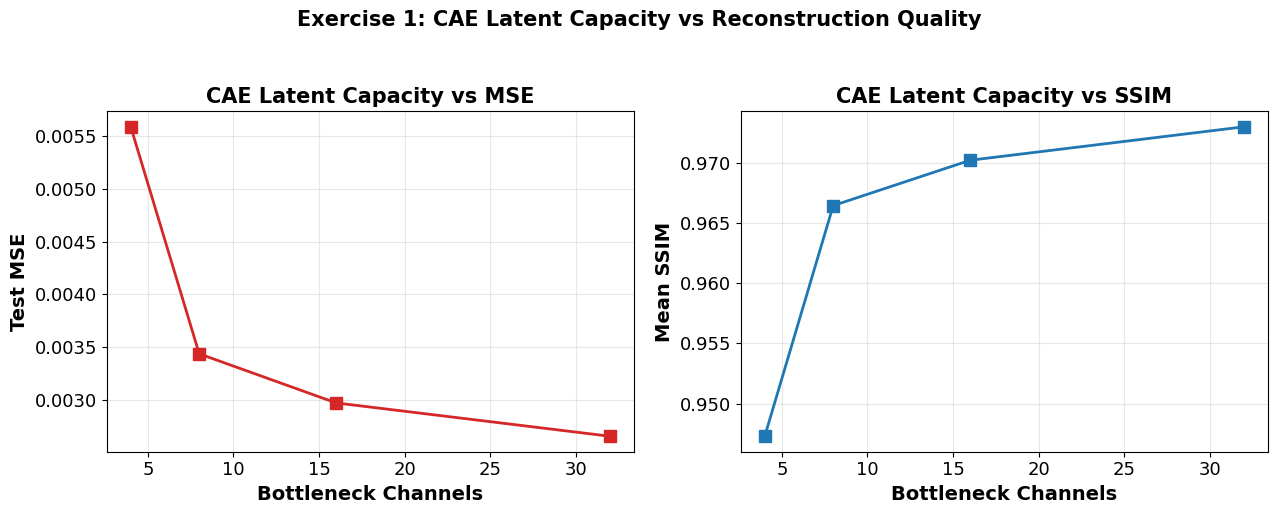

CAE Latent Dimension Sweep:
  channels=4: MSE=0.00559 SSIM=0.9473 Params=22597
  channels=8: MSE=0.00343 SSIM=0.9665 Params=26057
  channels=16: MSE=0.00297 SSIM=0.9702 Params=32977
  channels=32: MSE=0.00265 SSIM=0.9730 Params=46817


In [35]:
fig, axs = plt.subplots(1,2, figsize=(13,5))
mse_vals = [cae_dim_results[d]['metrics']['MSE'] for d in cae_latent_dims]
ssim_vals = [cae_dim_results[d]['metrics']['SSIM'] for d in cae_latent_dims]

axs[0].plot(cae_latent_dims, mse_vals, marker='s', linewidth=2, markersize=8, color='tab:red')
axs[0].set_xlabel('Bottleneck Channels', fontweight='bold')
axs[0].set_ylabel('Test MSE', fontweight='bold')
axs[0].set_title('CAE Latent Capacity vs MSE', fontweight='bold')
axs[0].grid(alpha=0.3)

axs[1].plot(cae_latent_dims, ssim_vals, marker='s', linewidth=2, markersize=8, color='tab:blue')
axs[1].set_xlabel('Bottleneck Channels', fontweight='bold')
axs[1].set_ylabel('Mean SSIM', fontweight='bold')
axs[1].set_title('CAE Latent Capacity vs SSIM', fontweight='bold')
axs[1].grid(alpha=0.3)

fig.suptitle('Exercise 1: CAE Latent Capacity vs Reconstruction Quality', fontweight='bold', y=1.03)
plt.tight_layout()
save_fig(fig, 'ex1_cae_latent_dim_sweep.png')

print("CAE Latent Dimension Sweep:")
for d in cae_latent_dims:
    m = cae_dim_results[d]['metrics']
    print(f"  channels={d}: MSE={m['MSE']:.5f} SSIM={m['SSIM']:.4f} Params={m['Parameters']}")

**Inference (fill after reviewing output):**
- Compare this trend to the FC-AE sweep (Section 27) — is convolutional capacity more or less sensitive: _[fill after run]_

## 11. Additional Exercise 5 — VAE with Latent Dim 8 (vs Latent Dim 2)

Latent dim 8 cannot be visualized directly as a 2D scatter; a 2D PCA projection of the 8-D means is used instead for a qualitative comparison plot only (not one of the manual's 10 required plots).

**Expect ~4-5 minutes.**

In [36]:
vae8 = VAE(latent_dim=8, beta=1.0)
vae8.compile(optimizer=keras.optimizers.Adam(1e-3))

t0 = time.time()
vae8_history = vae8.fit(
    x_train_img, x_train_img,
    validation_data=(x_test_img, x_test_img),
    epochs=20, batch_size=128, shuffle=True, verbose=1
)
vae8_train_time = time.time() - t0

z_mean8, z_log_var8, z8 = vae8.encoder.predict(x_test_img, verbose=0)
vae8_recon = vae8.decoder.predict(z8, verbose=0)
vae8_metrics = compute_metrics(x_test_img, vae8_recon)
vae8_metrics.update({
    'ReconstructionLoss': float(vae8_history.history['val_recon_loss'][-1]),
    'KLLoss': float(vae8_history.history['val_kl_loss'][-1]),
    'TotalLoss': float(vae8_history.history['val_loss'][-1]),
    'Parameters': count_params(vae8.encoder) + count_params(vae8.decoder),
    'TrainTime_s': round(vae8_train_time, 1)
})
print("VAE (latent=8) metrics:", vae8_metrics)
ALL_METRICS['VAE_latent8'] = vae8_metrics
save_checkpoint('vae_latent8', vae8_metrics, vae8)

print("\nComparison — VAE latent=2 vs latent=8:")
print(f"  latent=2: MSE={vae2_metrics['MSE']:.5f} SSIM={vae2_metrics['SSIM']:.4f} ReconLoss={vae2_metrics['ReconstructionLoss']:.2f} KL={vae2_metrics['KLLoss']:.2f}")
print(f"  latent=8: MSE={vae8_metrics['MSE']:.5f} SSIM={vae8_metrics['SSIM']:.4f} ReconLoss={vae8_metrics['ReconstructionLoss']:.2f} KL={vae8_metrics['KLLoss']:.2f}")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - kl_loss: 4.5113 - loss: 281.9363 - recon_loss: 277.4250 - val_kl_loss: 3.0965 - val_loss: 210.4465 - val_recon_loss: 207.3500
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.7525 - loss: 206.9363 - recon_loss: 203.1837 - val_kl_loss: 4.0912 - val_loss: 195.5632 - val_recon_loss: 191.4720
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 6.6963 - loss: 185.4194 - recon_loss: 178.7231 - val_kl_loss: 8.3606 - val_loss: 175.4996 - val_recon_loss: 167.1390
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 9.9302 - loss: 165.9700 - recon_loss: 156.0398 - val_kl_loss: 11.1092 - val_loss: 157.3830 - val_recon_loss: 146.2738
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 12.7844 - loss: 146.5500 - recon_loss: 133.7655 - val_kl_loss: 13.6015 - val_loss: 145.5768 - val_recon_loss: 131.9753
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 13.8219 - loss: 137.8856 - recon_loss: 124.06

[plot saved] ex5_vae_latent2_vs_latent8.png


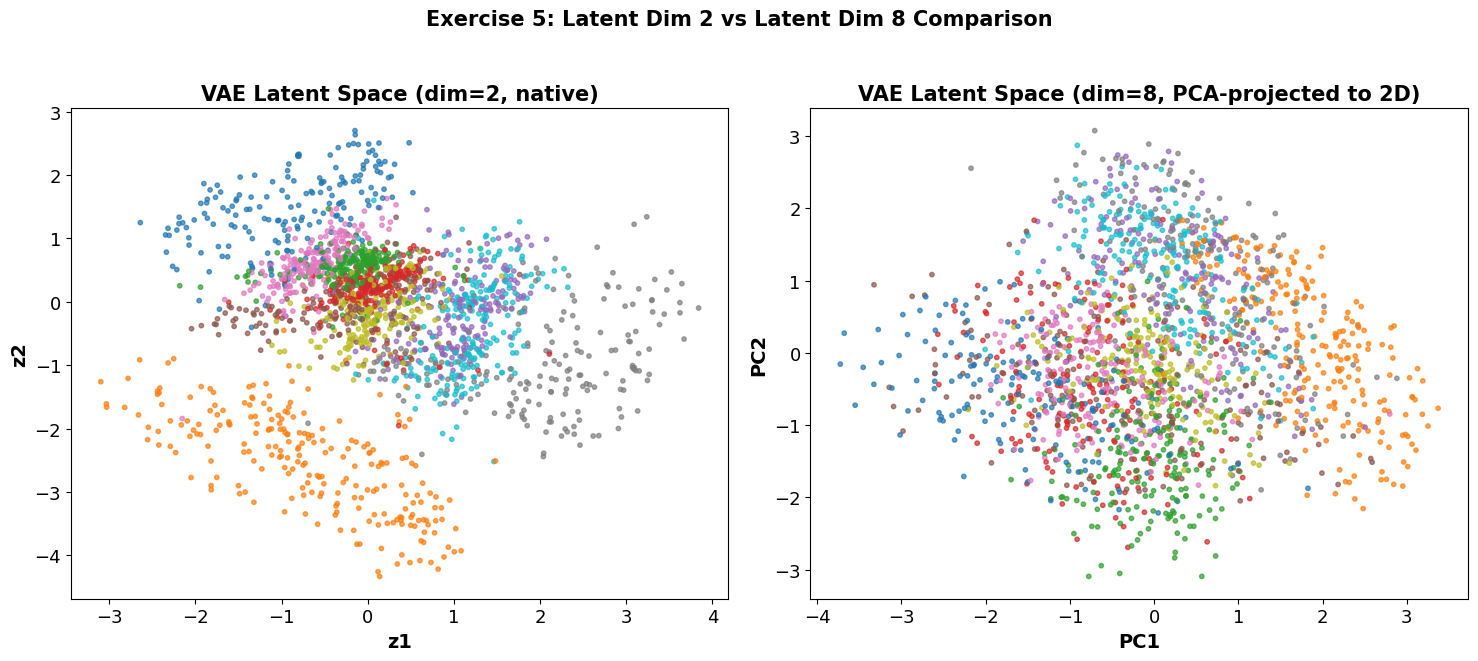

In [37]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=SEED)
z8_pca = pca.fit_transform(z_mean8)

fig, axs = plt.subplots(1,2, figsize=(15,6.5))
sc0 = axs[0].scatter(z_mean_test[:,0], z_mean_test[:,1], c=y_test, cmap='tab10', s=10, alpha=0.7)
axs[0].set_title('VAE Latent Space (dim=2, native)', fontweight='bold')
axs[0].set_xlabel('z1', fontweight='bold'); axs[0].set_ylabel('z2', fontweight='bold')

sc1 = axs[1].scatter(z8_pca[:,0], z8_pca[:,1], c=y_test, cmap='tab10', s=10, alpha=0.7)
axs[1].set_title('VAE Latent Space (dim=8, PCA-projected to 2D)', fontweight='bold')
axs[1].set_xlabel('PC1', fontweight='bold'); axs[1].set_ylabel('PC2', fontweight='bold')

fig.suptitle('Exercise 5: Latent Dim 2 vs Latent Dim 8 Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'ex5_vae_latent2_vs_latent8.png')

**Inference (fill after reviewing output):**
- Reconstruction quality difference (latent=2 vs 8): _[fill after run]_
- Cluster separation difference: _[fill after run]_

## 12. Additional Exercise 6 — Effect of Increasing KL-Loss Contribution (β-VAE Ablation)

Trains VAE (latent=2) with β ∈ {0.5, 1.0, 5.0} to observe the reconstruction/regularization trade-off as the KL term is up-weighted.

**Expect ~10-12 minutes for the 3 runs (β=1.0 reuses the run above).**

In [38]:
beta_values = [0.5, 1.0, 5.0]
beta_results = {1.0: {'metrics': vae2_metrics, 'model': vae2, 'z_mean': z_mean_test}}

for beta in [b for b in beta_values if b != 1.0]:
    print(f"\n=== Training VAE (latent=2), beta={beta} ===")
    model = VAE(latent_dim=2, beta=beta)
    model.compile(optimizer=keras.optimizers.Adam(1e-3))
    t0 = time.time()
    hist = model.fit(x_train_img, x_train_img,
              validation_data=(x_test_img, x_test_img),
              epochs=20, batch_size=128, shuffle=True, verbose=1)
    train_time = time.time() - t0

    zm, zlv, z = model.encoder.predict(x_test_img, verbose=0)
    recon = model.decoder.predict(z, verbose=0)
    metrics = compute_metrics(x_test_img, recon)
    # Pull loss breakdown from the logged history (last epoch, validation split),
    # not from the tracker objects directly -- tracker .result() after fit() is unreliable.
    metrics.update({
        'ReconstructionLoss': float(hist.history['val_recon_loss'][-1]),
        'KLLoss': float(hist.history['val_kl_loss'][-1]),
        'TotalLoss': float(hist.history['val_loss'][-1]),
        'TrainTime_s': round(train_time, 1)
    })
    beta_results[beta] = {'metrics': metrics, 'model': model, 'z_mean': zm}
    print(f"beta={beta}: {metrics}")
    save_checkpoint(f'vae_beta_{beta}', metrics, model)

ALL_METRICS['VAE_BetaAblation'] = {str(b): beta_results[b]['metrics'] for b in beta_values}


=== Training VAE (latent=2), beta=0.5 ===
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - kl_loss: 3.6654 - loss: 308.2409 - recon_loss: 306.4082 - val_kl_loss: 5.4276 - val_loss: 209.6281 - val_recon_loss: 206.9142
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 5.2432 - loss: 206.8119 - recon_loss: 204.1903 - val_kl_loss: 5.9895 - val_loss: 198.9523 - val_recon_loss: 195.9575
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 5.3833 - loss: 195.8251 - recon_loss: 193.1334 - val_kl_loss: 5.4871 - val_loss: 184.7361 - val_recon_loss: 181.9925
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 5.6342 - loss: 181.2222 - recon_loss: 178.4051 - val_kl_loss: 5.5410 - val_loss: 174.4178 - val_recon_loss: 171.6474
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 5.6589 - loss: 173.7824 - recon_loss: 170.9529 - val_kl_loss: 5.8786 - val_loss: 170.0153 - val_recon_loss: 167.0759
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 5.775

[plot saved] ex6_beta_vae_latent_space.png


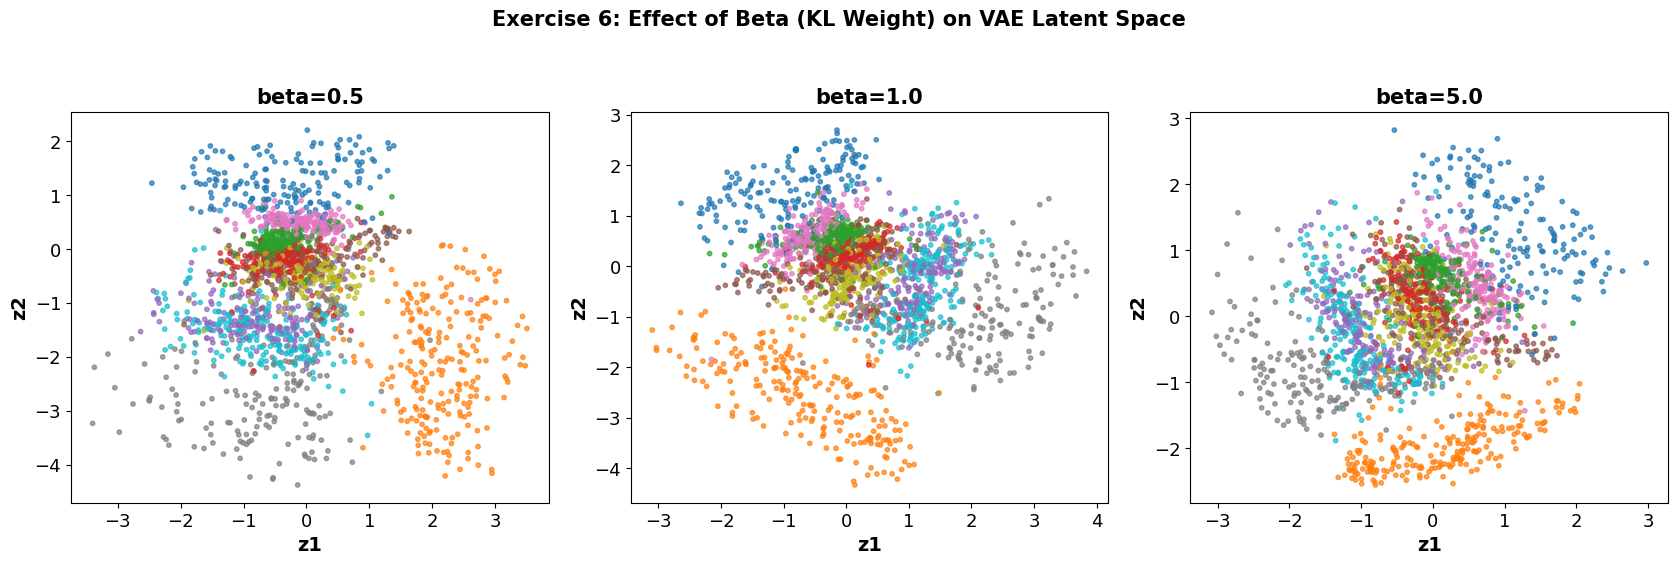

Beta ablation — reconstruction vs KL trade-off:
  beta=0.5: MSE=0.04346 SSIM=0.5133 ReconLoss=147.27108764648438 KL=6.783523082733154
  beta=1.0: MSE=0.04475 SSIM=0.5007 ReconLoss=150.06326293945312 KL=5.43938684463501
  beta=5.0: MSE=0.04856 SSIM=0.4614 ReconLoss=161.272216796875 KL=3.044680595397949


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17,5.5))
for ax, beta in zip(axes, beta_values):
    zm = beta_results[beta]['z_mean']
    sc = ax.scatter(zm[:,0], zm[:,1], c=y_test, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f'beta={beta}', fontweight='bold')
    ax.set_xlabel('z1', fontweight='bold'); ax.set_ylabel('z2', fontweight='bold')
fig.suptitle('Exercise 6: Effect of Beta (KL Weight) on VAE Latent Space', fontweight='bold', y=1.03)
plt.tight_layout()
save_fig(fig, 'ex6_beta_vae_latent_space.png')

print("Beta ablation — reconstruction vs KL trade-off:")
for b in beta_values:
    m = beta_results[b]['metrics']
    print(f"  beta={b}: MSE={m['MSE']:.5f} SSIM={m['SSIM']:.4f} ReconLoss={m.get('ReconstructionLoss','n/a')} KL={m.get('KLLoss','n/a')}")

**Inference (fill after reviewing output):**
- Effect of increasing beta on reconstruction sharpness vs latent regularization: _[fill after run]_

## 13. Additional Exercise 7 — Larger VAE Sample Grid (100 samples) and Diversity Discussion

[plot saved] ex7_vae_100_samples.png


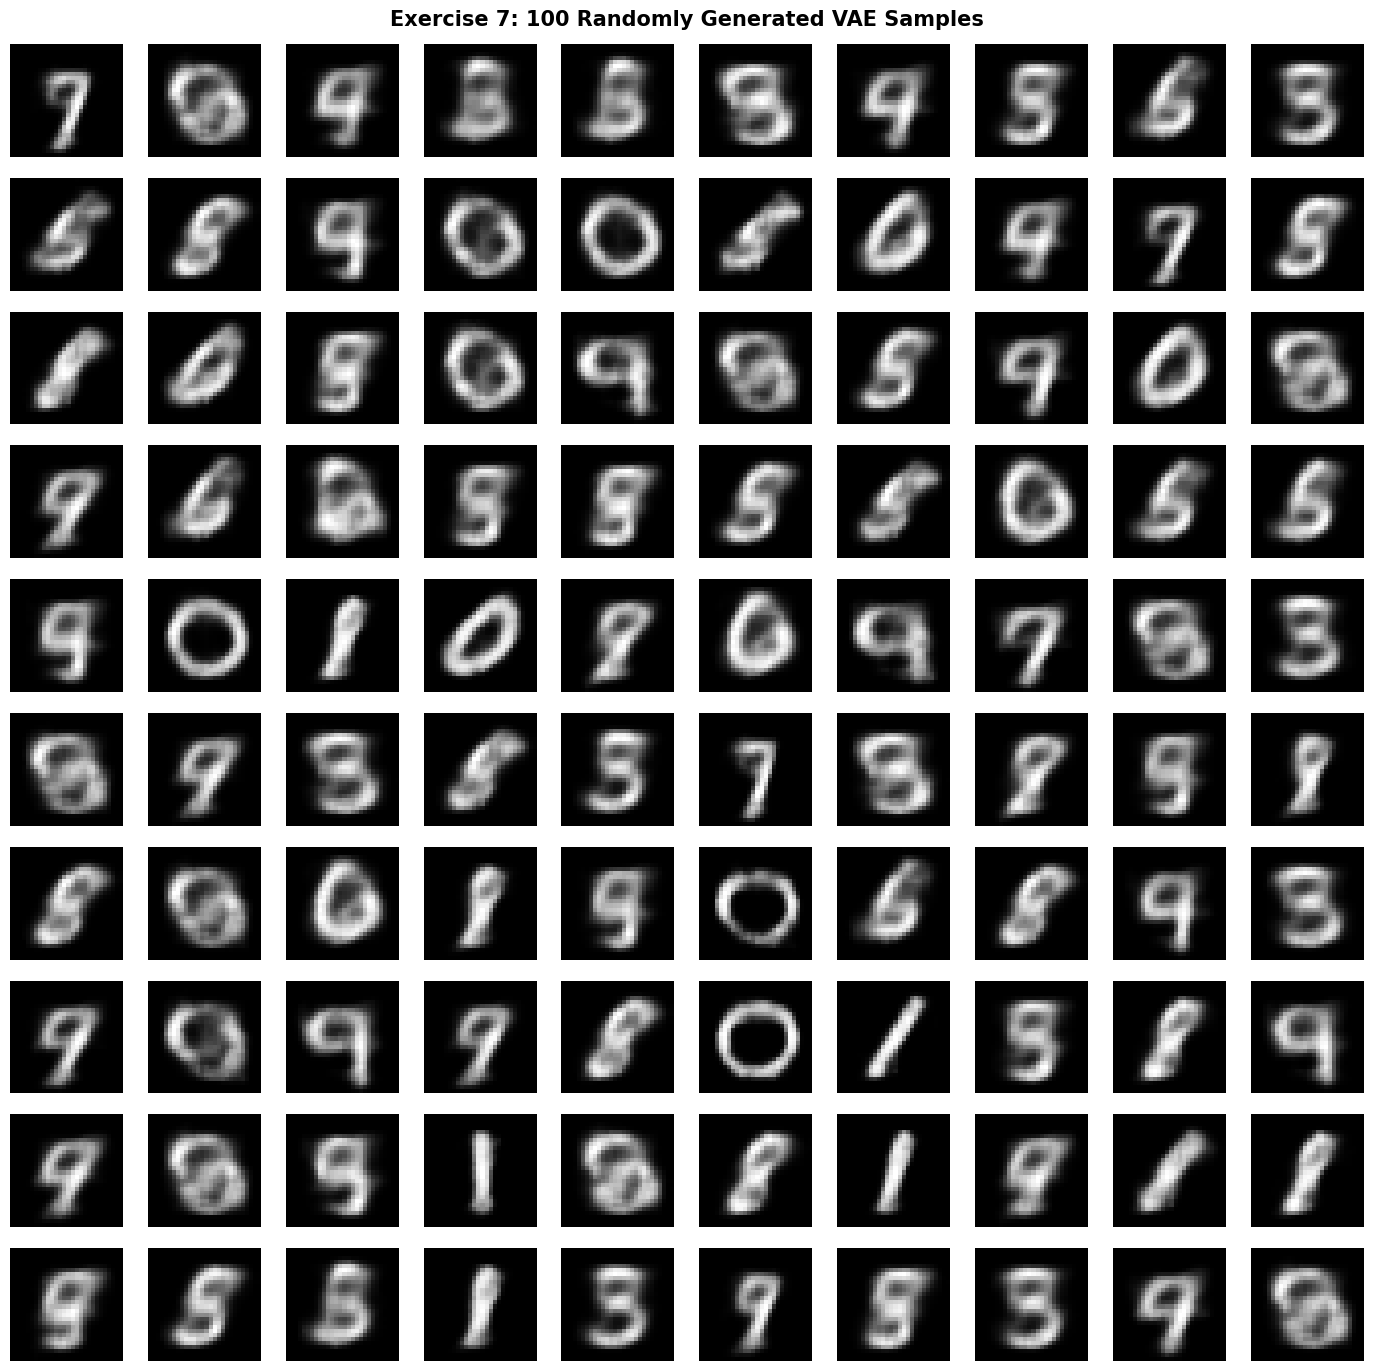

In [40]:
z_random_large = gen_rng.normal(0, 1, size=(100, 2)).astype('float32')
generated_large = vae2.decoder.predict(z_random_large, verbose=0)

fig, axes = plt.subplots(10, 10, figsize=(14,14))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_large[i].reshape(28,28), cmap='gray')
    ax.axis('off')
fig.suptitle('Exercise 7: 100 Randomly Generated VAE Samples', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'ex7_vae_100_samples.png')

**Inference (fill after reviewing output):**
- Diversity across the larger sample set — new observations vs the 25-sample grid: _[fill after run]_

## 14. Additional Exercise 8 — Targeted Digit-Region Interpolation

Selects two digit-cluster centroids (computed from encoded test means, grouped by label) rather than two arbitrary points, then interpolates between the centroids.

Selected digit pair (max latent-space separation): 0 and 1, distance=3.907
[plot saved] ex8_centroid_interpolation.png


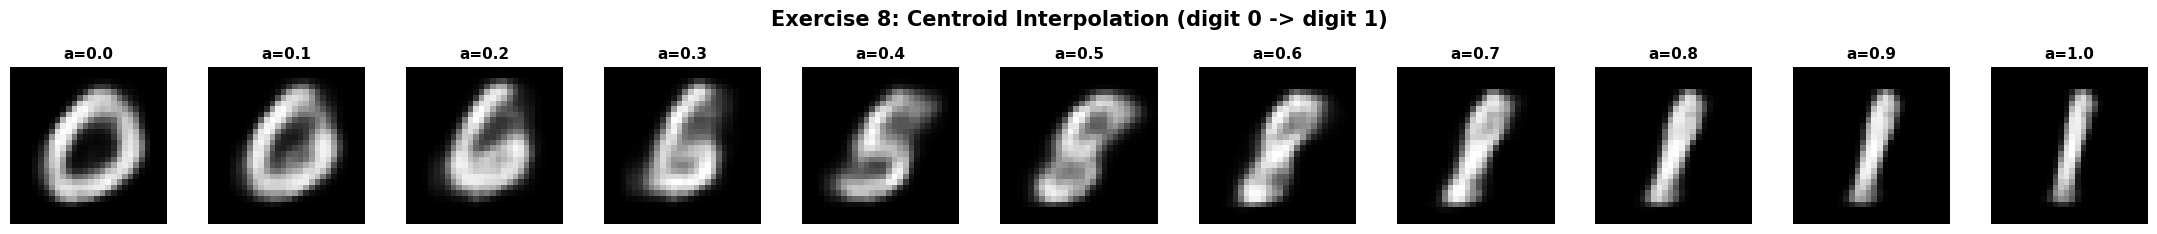

In [41]:
# Compute per-digit centroid in latent space, pick the two most visually distinct
# (largest Euclidean distance apart) for a clean interpolation
centroids = {d: z_mean_test[y_test == d].mean(axis=0) for d in range(10)}
dists = {}
for d1 in range(10):
    for d2 in range(d1+1, 10):
        dists[(d1,d2)] = np.linalg.norm(centroids[d1] - centroids[d2])
best_pair = max(dists, key=dists.get)
digit_c, digit_d = best_pair
print(f"Selected digit pair (max latent-space separation): {digit_c} and {digit_d}, distance={dists[best_pair]:.3f}")

zC, zD = centroids[digit_c], centroids[digit_d]
alphas2 = np.linspace(0, 1, 11)
z_interp2 = np.array([(1-a)*zC + a*zD for a in alphas2]).astype('float32')
decoded_interp2 = vae2.decoder.predict(z_interp2, verbose=0)

fig, axes = plt.subplots(1, 11, figsize=(22,2.4))
for i, ax in enumerate(axes):
    ax.imshow(decoded_interp2[i].reshape(28,28), cmap='gray')
    ax.set_title(f'a={alphas2[i]:.1f}', fontsize=11, fontweight='bold')
    ax.axis('off')
fig.suptitle(f'Exercise 8: Centroid Interpolation (digit {digit_c} -> digit {digit_d})', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'ex8_centroid_interpolation.png')

**Inference (fill after reviewing output):**
- Compare this centroid-based interpolation to Plot 8's arbitrary-point interpolation: _[fill after run]_

## 15. Consolidated Results Table (Section 25)

In [42]:
import pandas as pd

consolidated = pd.DataFrame([
    {'Model': 'FC Autoencoder', 'MSE': fc_metrics['MSE'], 'MAE': fc_metrics['MAE'],
     'SSIM': fc_metrics['SSIM'], 'Parameters': fc_metrics['Parameters'], 'Time_s': fc_metrics['TrainTime_s']},
    {'Model': 'Convolutional AE (UpSampling)', 'MSE': cae_metrics['MSE'], 'MAE': cae_metrics['MAE'],
     'SSIM': cae_metrics['SSIM'], 'Parameters': cae_metrics['Parameters'], 'Time_s': cae_metrics['TrainTime_s']},
    {'Model': 'Convolutional AE (Conv2DTranspose)', 'MSE': cae_t_metrics['MSE'], 'MAE': cae_t_metrics['MAE'],
     'SSIM': cae_t_metrics['SSIM'], 'Parameters': cae_t_metrics['Parameters'], 'Time_s': cae_t_metrics['TrainTime_s']},
    {'Model': 'Denoising CAE (Gaussian sigma=0.2)', 'MSE': denoising_results_gaussian[0.2]['metrics']['MSE'],
     'MAE': denoising_results_gaussian[0.2]['metrics']['MAE'], 'SSIM': denoising_results_gaussian[0.2]['metrics']['SSIM'],
     'Parameters': denoising_results_gaussian[0.2]['metrics']['Parameters'], 'Time_s': denoising_results_gaussian[0.2]['metrics']['TrainTime_s']},
    {'Model': 'Denoising CAE (Salt-Pepper p=0.10)', 'MSE': denoising_results_sp[0.10]['metrics']['MSE'],
     'MAE': denoising_results_sp[0.10]['metrics']['MAE'], 'SSIM': denoising_results_sp[0.10]['metrics']['SSIM'],
     'Parameters': denoising_results_sp[0.10]['metrics']['Parameters'], 'Time_s': denoising_results_sp[0.10]['metrics']['TrainTime_s']},
    {'Model': 'VAE (latent=2)', 'MSE': vae2_metrics['MSE'], 'MAE': vae2_metrics['MAE'],
     'SSIM': vae2_metrics['SSIM'], 'Parameters': vae2_metrics['Parameters'], 'Time_s': vae2_metrics['TrainTime_s']},
    {'Model': 'VAE (latent=8)', 'MSE': vae8_metrics['MSE'], 'MAE': vae8_metrics['MAE'],
     'SSIM': vae8_metrics['SSIM'], 'Parameters': vae8_metrics['Parameters'], 'Time_s': vae8_metrics['TrainTime_s']},
])
consolidated = consolidated.round({'MSE':5, 'MAE':5, 'SSIM':4})
print(consolidated.to_string(index=False))
consolidated.to_csv(os.path.join(CKPT_DIR, 'consolidated_results.csv'), index=False)
ALL_METRICS['ConsolidatedTable'] = consolidated.to_dict(orient='records')

                             Model     MSE     MAE   SSIM  Parameters  Time_s
                    FC Autoencoder 0.02252 0.05972 0.7452      211040    11.5
     Convolutional AE (UpSampling) 0.00246 0.01502 0.9751       74497    19.5
Convolutional AE (Conv2DTranspose) 0.00224 0.01402 0.9779       83745    19.1
Denoising CAE (Gaussian sigma=0.2) 0.00438 0.02087 0.9489       74497    17.2
Denoising CAE (Salt-Pepper p=0.10) 0.00458 0.02056 0.9497       74497    17.3
                    VAE (latent=2) 0.04475 0.10482 0.5007      284933    21.7
                    VAE (latent=8) 0.02135 0.05606 0.7737      304529    21.1


In [43]:
vae_specific = pd.DataFrame([
    {'VAE Config': 'latent=2, beta=1.0', 'ReconLoss': vae2_metrics['ReconstructionLoss'],
     'KLLoss': vae2_metrics['KLLoss'], 'TotalLoss': vae2_metrics['TotalLoss'],
     'MSE': vae2_metrics['MSE'], 'MAE': vae2_metrics['MAE'], 'SSIM': vae2_metrics['SSIM']},
    {'VAE Config': 'latent=8, beta=1.0', 'ReconLoss': vae8_metrics['ReconstructionLoss'],
     'KLLoss': vae8_metrics['KLLoss'], 'TotalLoss': vae8_metrics['TotalLoss'],
     'MSE': vae8_metrics['MSE'], 'MAE': vae8_metrics['MAE'], 'SSIM': vae8_metrics['SSIM']},
])
print(vae_specific.to_string(index=False))
vae_specific.to_csv(os.path.join(CKPT_DIR, 'vae_specific_results.csv'), index=False)

        VAE Config  ReconLoss    KLLoss  TotalLoss      MSE      MAE     SSIM
latent=2, beta=1.0 150.063263  5.439387 155.502655 0.044746 0.104817 0.500696
latent=8, beta=1.0 101.721016 16.510544 118.231560 0.021353 0.056061 0.773742


## 16. Discussion Questions (Section 28) — Answer Scaffold

The 25 discussion questions are conceptual and are meant to be answered in the written report, not as code output. Listed here for completeness and so answers can reference the actual numbers/plots produced above. **Do not answer these in the notebook** — they belong in the LaTeX report; we'll draft them together once results are back.

1. What is an autoencoder?
2. What is the purpose of the encoder?
3. What is the purpose of the decoder?
4. What is a latent representation?
5. Why is the latent representation usually smaller than the input?
6. What happens when the latent dimension is too small? *(reference Plot 10 / Exercise 1 sweep)*
7. What happens when the latent dimension is increased? *(reference Plot 10 / Exercise 1 sweep)*
8. Why can a convolutional autoencoder preserve spatial information more effectively? *(reference Plot 3)*
9. Differentiate an autoencoder and a denoising autoencoder.
10. Why is the clean image used as the target in denoising?
11. What happens when the noise level is increased? *(reference Plot 5)*
12. Why are MSE, MAE and SSIM useful for image reconstruction?
13. What is a Variational Autoencoder?
14. How does a VAE differ from a conventional autoencoder?
15. Why does a VAE learn a distribution instead of a single latent vector?
16. What is the reparameterization trick?
17. Why is ε sampled from a standard normal distribution?
18. What is the role of KL divergence in the VAE loss? *(reference Exercise 6 beta ablation)*
19. What is the prior distribution used in the VAE?
20. Why is a two-dimensional latent space useful for visualization? *(reference Plot 6)*
21. What does latent-space interpolation demonstrate? *(reference Plot 8 / Exercise 8)*
22. Why can a VAE generate new images? *(reference Plot 7)*
23. Why might some VAE-generated images be unclear? *(reference Plot 7)*
24. What is the difference between reconstruction and generation?
25. Why should test images remain unseen during training?


## 17. Save All Metrics and Package Plots for Download

In [44]:
# Save the full ALL_METRICS dict as one JSON for easy reference when writing the report
with open(os.path.join(CKPT_DIR, 'ALL_METRICS_SUMMARY.json'), 'w') as f:
    json.dump(ALL_METRICS, f, indent=2, default=str)
print("Saved ALL_METRICS_SUMMARY.json")
print(json.dumps(ALL_METRICS, indent=2, default=str)[:2000], "...")

Saved ALL_METRICS_SUMMARY.json
{
  "FC_AE": {
    "MSE": 0.02252386510372162,
    "MAE": 0.05971858650445938,
    "SSIM": 0.7452111643011737,
    "Parameters": 211040,
    "TrainTime_s": 11.5
  },
  "CAE_UpSampling": {
    "MSE": 0.0024648138787597418,
    "MAE": 0.015024429187178612,
    "SSIM": 0.9751458648933995,
    "Parameters": 74497,
    "TrainTime_s": 19.5
  },
  "CAE_Transpose": {
    "MSE": 0.002240729983896017,
    "MAE": 0.014018394984304905,
    "SSIM": 0.9779299361812517,
    "Parameters": 83745,
    "TrainTime_s": 19.1
  },
  "Denoising_Gaussian": {
    "0.1": {
      "MSE": 0.0029865496326237917,
      "MAE": 0.01682748831808567,
      "SSIM": 0.9665584554656034,
      "Parameters": 74497,
      "TrainTime_s": 17.3,
      "NoiseType": "gaussian",
      "NoiseLevel": 0.1
    },
    "0.2": {
      "MSE": 0.0043843029998242855,
      "MAE": 0.020869629457592964,
      "SSIM": 0.9489018065549222,
      "Parameters": 74497,
      "TrainTime_s": 17.2,
      "NoiseType": "gaus

In [45]:
# Zip the plots folder for guaranteed download even if Kaggle disconnects afterward
zip_path = '/kaggle/working/experiment7_plots.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(PLOTS_DIR):
        for file in files:
            filepath = os.path.join(root, file)
            arcname = os.path.relpath(filepath, PLOTS_DIR)
            zf.write(filepath, arcname)

print(f"Zipped {len(os.listdir(PLOTS_DIR))} plot files to {zip_path}")

# Also zip checkpoints (metrics json + csv) separately for report-writing reference
ckpt_zip_path = '/kaggle/working/experiment7_checkpoints.zip'
with zipfile.ZipFile(ckpt_zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(CKPT_DIR):
        for file in files:
            if file.endswith('.json') or file.endswith('.csv'):
                filepath = os.path.join(root, file)
                arcname = os.path.relpath(filepath, CKPT_DIR)
                zf.write(filepath, arcname)

print(f"Zipped metrics/checkpoints to {ckpt_zip_path}")
print("\nBoth zip files are in /kaggle/working/ — download them from the Kaggle output panel before the session ends.")

Zipped 19 plot files to /kaggle/working/experiment7_plots.zip
Zipped metrics/checkpoints to /kaggle/working/experiment7_checkpoints.zip

Both zip files are in /kaggle/working/ — download them from the Kaggle output panel before the session ends.


---
### End of notebook.

**Next steps after running:**
1. Download `experiment7_plots.zip` and `experiment7_checkpoints.zip` from the Kaggle output panel.
2. Upload the executed `.ipynb` (with outputs) back here.
3. I'll extract the real MSE/MAE/SSIM/loss numbers and fill in every "[fill after run]" inference with 2–3 crisp sentences per plot, in your voice, based on actual results — not invented numbers.
4. Then we move to the LaTeX report, README, and GitHub structure — one step at a time, confirming format before I generate anything.
